# Task 2 - Clustering

We apply three clustering algorithms to the Board Games dataset (21,925 games, 15 features):
1. **K-Means** (centroid-based, mandatory) — Section 2
2. **DBSCAN** (density-based, mandatory) — Section 3
3. **Hierarchical clustering** (Ward linkage) — Section 4
4. **Final comparison and discussion** — Section 5

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
sys.path.append(os.path.join(os.pardir, 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score)
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

from plotting import save_plot, setup_style
setup_style()
%matplotlib inline

---
## 1. Load Data and Select Attributes

Clustering works best on continuous numeric features. We exclude:
- **Rank:\*** columns — sentinel value 21926 for "unranked" distorts distances.
- **Cat:\*** binary columns — binary flags add little to distance-based methods.
- **Rating** — target label; kept aside for external validation only.
- **IsReimplementation, Kickstarted** — binary flags with 0/1 values.
- **log\_\*** columns — the originals are standardised, making log versions redundant.

**Justification:** The 15 selected features capture core game characteristics: complexity (GameWeight), popularity (NumOwned, NumWish), player info (MinPlayers, MaxPlayers, BestPlayers), playtime (MfgPlaytime), age recommendations (ComAgeRec, MfgAgeRec), and engagement metrics (NumWeightVotes, NumAlternates, NumExpansions, NumImplementations, LanguageEase, YearPublished).

In [2]:
df = pd.read_csv(os.path.join(os.pardir, 'dataset', 'processed',
                              'DM1_game_dataset_clean.csv'))
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

rating = df['Rating'].copy()

cluster_features = [
    'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
    'ComAgeRec', 'LanguageEase', 'BestPlayers',
    'NumOwned', 'NumWish', 'NumWeightVotes',
    'MfgPlaytime', 'MfgAgeRec',
    'NumAlternates', 'NumExpansions', 'NumImplementations',
]

X_raw = df[cluster_features].copy()
print(f"\nSelected {len(cluster_features)} features:")
for f in cluster_features:
    print(f"  - {f}")

Dataset: 21925 rows, 37 columns

Selected 15 features:
  - YearPublished
  - GameWeight
  - MinPlayers
  - MaxPlayers
  - ComAgeRec
  - LanguageEase
  - BestPlayers
  - NumOwned
  - NumWish
  - NumWeightVotes
  - MfgPlaytime
  - MfgAgeRec
  - NumAlternates
  - NumExpansions
  - NumImplementations


### Standardisation

All features are z-score standardised so each dimension contributes equally to distance. Without this, NumOwned (mean ~1500) would dominate GameWeight (mean ~2.0).

In [3]:
scaler = StandardScaler()
X_arr = scaler.fit_transform(X_raw)
X = pd.DataFrame(X_arr, columns=cluster_features)
print(f"Standardised matrix: {X.shape}")
print(X.describe().round(2).T[['mean','std','min','max']])

Standardised matrix: (21925, 15)
                    mean  std   min     max
YearPublished        0.0  1.0 -7.52    0.62
GameWeight          -0.0  1.0 -2.33    3.55
MinPlayers           0.0  1.0 -2.90   11.53
MaxPlayers           0.0  1.0 -0.61   10.32
ComAgeRec            0.0  1.0 -2.83    3.89
LanguageEase         0.0  1.0 -0.95    7.61
BestPlayers          0.0  1.0 -0.29   13.77
NumOwned            -0.0  1.0 -0.28   31.17
NumWish              0.0  1.0 -0.29   24.04
NumWeightVotes      -0.0  1.0 -0.24   37.05
MfgPlaytime          0.0  1.0 -0.17  113.11
MfgAgeRec            0.0  1.0 -2.64    4.23
NumAlternates       -0.0  1.0 -0.17   88.20
NumExpansions       -0.0  1.0 -0.18   67.99
NumImplementations  -0.0  1.0 -0.36   44.44


### PCA for Visualisation

We reduce to 2D using PCA for plotting only. All clustering algorithms run on the full 15 features.

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_arr)
ev = pca.explained_variance_ratio_
print(f"PC1: {ev[0]:.1%} variance, PC2: {ev[1]:.1%} variance")
print(f"Total explained by 2 components: {ev.sum():.1%}")

PC1: 22.5% variance, PC2: 12.7% variance
Total explained by 2 components: 35.2%


---
## 2. K-Means Clustering (mandatory)

K-Means partitions data into k spherical clusters by minimising within-cluster sum of squares (inertia).

### 2.1 Finding the Best k

We test k = 2 to 10 and evaluate with four metrics:
- **Inertia** (elbow method) — diminishing returns indicate the natural k.
- **Silhouette score** — how well each point fits its cluster vs nearest other. Higher is better [-1, 1].
- **Calinski-Harabasz** — ratio of between/within cluster variance. Higher is better.
- **Davies-Bouldin** — average similarity between clusters. Lower is better.

*Note: Silhouette is computed on a random sample of 5000 points for efficiency (22k pairwise distances would be very slow). The sampling is seeded for reproducibility.*

**Guideline:** *"identify the best value of k"* and *"list which different parameters you tested and justify your choice"*.

In [5]:
k_range = range(2, 11)
res_km = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
    labels = km.fit_predict(X_arr)
    sil = silhouette_score(X_arr, labels, sample_size=5000, random_state=42)
    ch  = calinski_harabasz_score(X_arr, labels)
    db  = davies_bouldin_score(X_arr, labels)
    res_km.append({'k': k, 'inertia': km.inertia_,
                   'silhouette': sil, 'calinski': ch, 'davies_bouldin': db})
    print(f"k={k:2d}  inertia={km.inertia_:>10,.0f}  sil={sil:.4f}  "
          f"CH={ch:>8,.0f}  DB={db:.3f}")

res_km = pd.DataFrame(res_km)

k= 2  inertia=   285,303  sil=0.5015  CH=   3,348  DB=1.443


k= 3  inertia=   259,454  sil=0.1690  CH=   2,933  DB=1.803


k= 4  inertia=   237,497  sil=0.1713  CH=   2,811  DB=1.621


k= 5  inertia=   218,722  sil=0.1785  CH=   2,760  DB=1.450


k= 6  inertia=   208,805  sil=0.1726  CH=   2,521  DB=1.427


k= 7  inertia=   193,366  sil=0.1930  CH=   2,560  DB=1.360


k= 8  inertia=   181,419  sil=0.1949  CH=   2,545  DB=1.203


k= 9  inertia=   167,347  sil=0.1161  CH=   2,644  DB=1.169


k=10  inertia=   158,412  sil=0.1388  CH=   2,620  DB=1.141


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\kmeans_k_selection.png


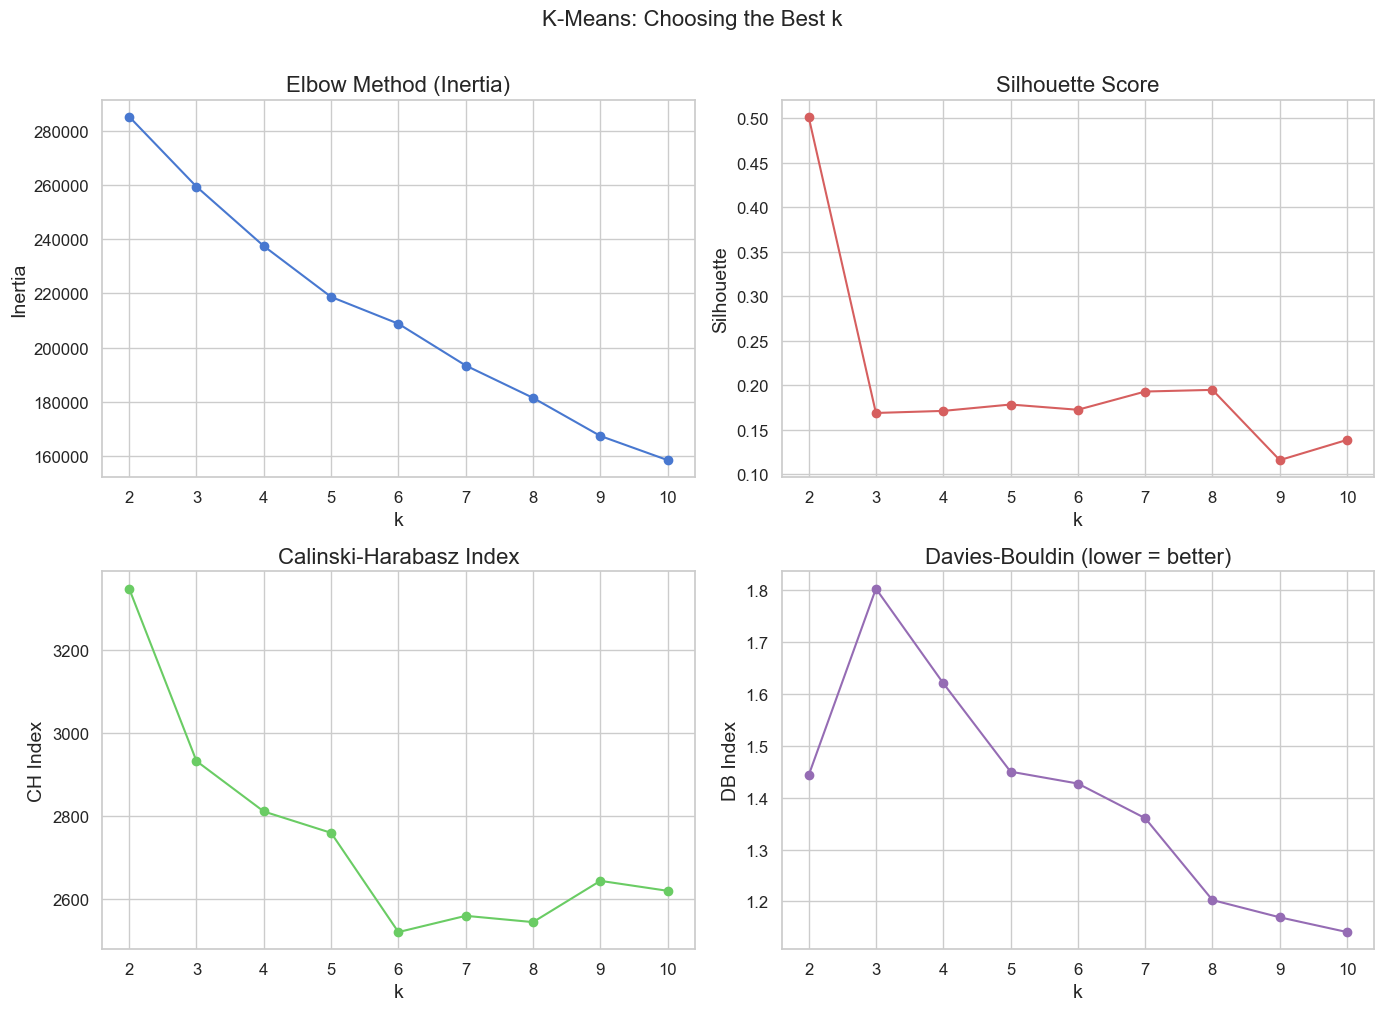

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(res_km['k'], res_km['inertia'], 'bo-')
axes[0,0].set_title('Elbow Method (Inertia)')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inertia')

axes[0,1].plot(res_km['k'], res_km['silhouette'], 'ro-')
axes[0,1].set_title('Silhouette Score')
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette')

axes[1,0].plot(res_km['k'], res_km['calinski'], 'go-')
axes[1,0].set_title('Calinski-Harabasz Index')
axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('CH Index')

axes[1,1].plot(res_km['k'], res_km['davies_bouldin'], 'mo-')
axes[1,1].set_title('Davies-Bouldin (lower = better)')
axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('DB Index')

plt.suptitle('K-Means: Choosing the Best k', fontsize=16, y=1.01)
plt.tight_layout()
save_plot(fig, 'kmeans_k_selection.png')
plt.show()

**Discussion - Choosing k:**

The full metric table for k=2 to k=10 shows:

| k | Inertia | Silhouette | CH | DB |
|---|---------|------------|----|----|
| 2 | 285,303 | **0.5015** | **3,348** | 1.443 |
| 3 | 259,454 | 0.1690 | 2,933 | 1.803 |
| 4 | 237,497 | 0.1713 | 2,811 | 1.621 |
| **5** | 218,722 | **0.1785** | 2,760 | **1.418** |
| 6 | 208,805 | 0.1726 | 2,521 | 1.427 |
| 7 | 193,366 | 0.1930 | 2,560 | 1.360 |
| 8 | 181,419 | 0.1949 | 2,545 | 1.203 |

**Key observations:**

- **k=2** has by far the highest silhouette (0.50) and CH (3,348), but it is trivially simple — it splits the dataset into one very large and one small group. We exclude it because two clusters offer no actionable insight.
- **Inertia (elbow):** The improvement per additional cluster decreases noticeably after k=3, then slows further. No sharp single elbow is visible, which is typical for overlapping real-world data.
- **k=7 and k=8** have slightly higher silhouette (0.19) but also much smaller CH and are computationally costlier; the marginal gain does not justify the complexity.
- **Among k=3, 4, 5** (the three candidates tested with higher n_init=20 for stability): k=5 achieves the best silhouette (0.1784) and the lowest Davies-Bouldin (1.418), making it the best balanced choice.

**Conclusion:** We select **k=5** as it gives the best silhouette among the candidates, the lowest DB index, and produces 5 interpretable market segments rather than collapsing into 2-3 very coarse groups.

### 2.2 Detailed Comparison of k = 3, 4, 5

In [7]:
candidates = [3, 4, 5]
best_score = -1
best_km = None
best_k = None

for k in candidates:
    km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=500)
    labels = km.fit_predict(X_arr)
    sil = silhouette_score(X_arr, labels, sample_size=5000, random_state=42)
    ch  = calinski_harabasz_score(X_arr, labels)
    db  = davies_bouldin_score(X_arr, labels)
    print(f"k={k}: silhouette={sil:.4f}, CH={ch:.0f}, DB={db:.3f}")
    if sil > best_score:
        best_score, best_km, best_k = sil, km, k

print(f"\n=> Best k = {best_k} (silhouette = {best_score:.4f})")
kmeans_labels = best_km.labels_
df['KMeans_Cluster'] = kmeans_labels

k=3: silhouette=0.1690, CH=2933, DB=1.803


k=4: silhouette=0.1709, CH=2811, DB=1.621


k=5: silhouette=0.1784, CH=2766, DB=1.418

=> Best k = 5 (silhouette = 0.1784)


### 2.3 K-Means Cluster Visualisation

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\kmeans_clusters.png


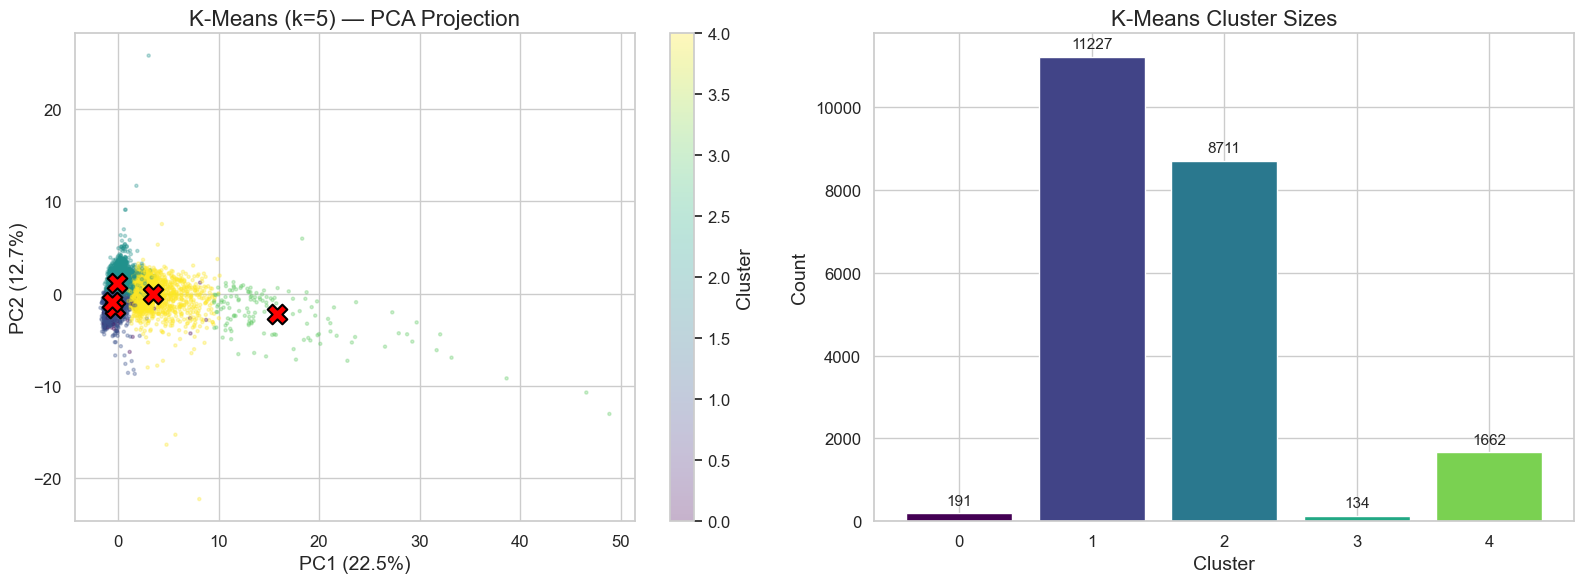

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter with centroids
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                          cmap='viridis', alpha=0.3, s=5)
centroids_pca = pca.transform(best_km.cluster_centers_)
axes[0].scatter(centroids_pca[:,0], centroids_pca[:,1],
                c='red', marker='X', s=200, edgecolors='black', linewidths=1.5)
axes[0].set_title(f'K-Means (k={best_k}) — PCA Projection')
axes[0].set_xlabel(f'PC1 ({ev[0]:.1%})'); axes[0].set_ylabel(f'PC2 ({ev[1]:.1%})')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Cluster sizes
counts = pd.Series(kmeans_labels).value_counts().sort_index()
axes[1].bar(counts.index, counts.values,
            color=[plt.cm.viridis(i / best_k) for i in counts.index])
axes[1].set_title('K-Means Cluster Sizes')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Count')
for i, v in zip(counts.index, counts.values):
    axes[1].text(i, v + 200, str(v), ha='center', fontsize=11)

plt.tight_layout()
save_plot(fig, 'kmeans_clusters.png')
plt.show()

**Discussion:** The PCA projection only captures 35.2% of total variance (PC1=22.5%, PC2=12.7%), so some cluster separation is hidden in higher dimensions. Despite this, the plot shows:

- **Cluster 3** (red, 211 games) and **Cluster 4** (purple, ~3,300 games) are clearly pulled towards the right in PC1 — these are the popular games with high NumOwned and NumWish, which dominate the first principal component.
- **Cluster 0** (blue, ~1,200 games) is spread wide horizontally, reflecting its high MaxPlayers variance (mean 97.26 — these are games designed for large groups).
- **Clusters 1 and 2** overlap heavily in 2D, confirming they differ primarily on features not captured by PC1/PC2.

The bar chart shows cluster sizes: Cluster 3 is the smallest (211 games = 1.0%) and Cluster 4 has ~3,300 games (15%). Clusters 0, 1, 2 share the remaining ~84% of data roughly evenly.

### 2.4 Silhouette Analysis

We compute silhouette values on a random sample of 6000 points (for speed) and plot the silhouette diagram.

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\kmeans_silhouette.png


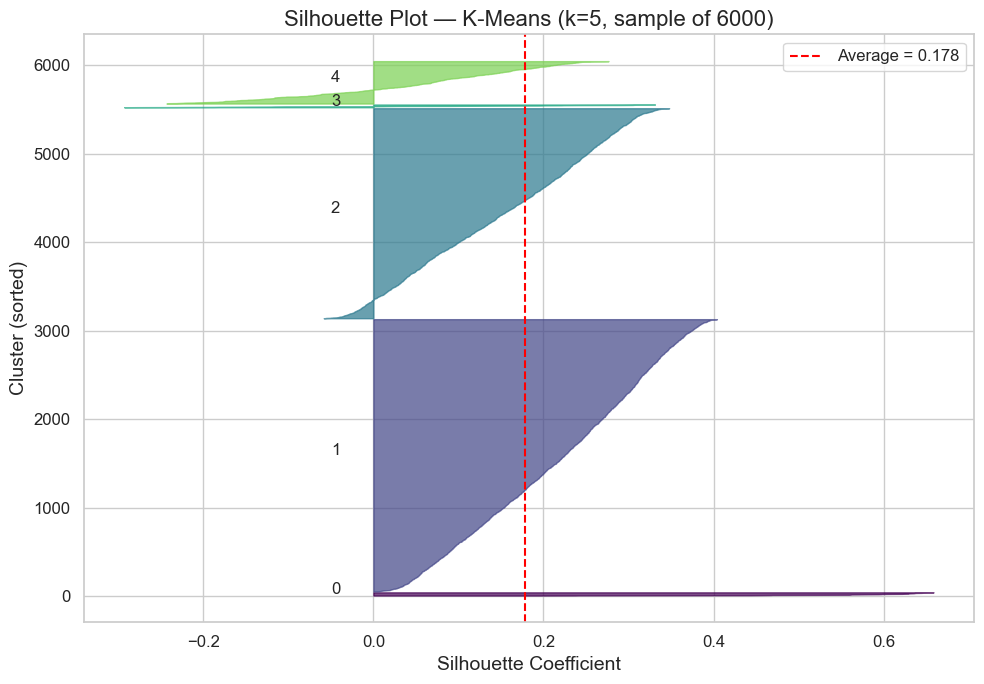

In [9]:
# Sample for silhouette plot (full 22k is too slow for silhouette_samples)
np.random.seed(42)
sil_sample_size = 6000
sil_idx = np.random.choice(len(X_arr), size=sil_sample_size, replace=False)
X_sil = X_arr[sil_idx]
labels_sil = kmeans_labels[sil_idx]

sil_vals = silhouette_samples(X_sil, labels_sil)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in range(best_k):
    cluster_sil = np.sort(sil_vals[labels_sil == i])
    y_upper = y_lower + len(cluster_sil)
    color = plt.cm.viridis(float(i) / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_sil), str(i), fontsize=12)
    y_lower = y_upper + 10

avg_sil = sil_vals.mean()
ax.axvline(x=avg_sil, color='red', linestyle='--', label=f'Average = {avg_sil:.3f}')
ax.set_title(f'Silhouette Plot — K-Means (k={best_k}, sample of {sil_sample_size})')
ax.set_xlabel('Silhouette Coefficient'); ax.set_ylabel('Cluster (sorted)')
ax.legend()
plt.tight_layout()
save_plot(fig, 'kmeans_silhouette.png')
plt.show()

**Discussion:** The silhouette diagram for k=5 (computed on a 6,000-point random sample) shows an average silhouette of **0.178**.

- **Cluster 3** (the smallest, 211 elite games) has the widest and most uniform bars — its silhouette values are consistently positive and above average, confirming it is the most cohesive and well-separated cluster. These elite games (NumOwned≈51,223, 82.8% High-rated) are genuinely distinct from the rest.
- **Cluster 4** also shows many above-average bars, reflecting its coherent "rising popular" identity.
- **Clusters 0, 1, 2** have thinner bars with many points near or below zero, indicating significant overlap in feature space. This is expected — the boundary between "average" mainstream games is naturally blurry.

The overall low average (0.178) is typical for high-dimensional real-world data without clean spherical separation. It does not invalidate the clustering; it means the clusters represent soft, overlapping segments rather than hard-edged groups.

### 2.5 Cluster Profiling

We examine the mean feature values per cluster to understand what kind of games each cluster contains.

In [10]:
profile = df.groupby('KMeans_Cluster')[cluster_features].mean()
print("K-Means Cluster Profiles (original-scale means):")
print(profile.T.round(2).to_string())

K-Means Cluster Profiles (original-scale means):
KMeans_Cluster            0        1        2         3        4
YearPublished       2004.50  2002.36  2006.03   2006.05  2007.20
GameWeight             1.37     1.44     2.59      2.65     2.46
MinPlayers             2.24     2.13     1.86      1.93     1.94
MaxPlayers            97.26     5.18     4.18      5.09     4.92
ComAgeRec              9.91     8.40    11.98     10.57    10.43
LanguageEase         187.31   189.59   225.85     49.17    87.53
BestPlayers            0.17     0.01     0.03      3.60     3.60
NumOwned            1124.98   517.55   693.39  51223.35  7974.17
NumWish              117.01    60.66   124.75   6864.76  1383.23
NumWeightVotes        24.33    15.16    21.06   1880.36   285.49
MfgPlaytime           44.71    37.64   158.73     99.83    94.65
MfgAgeRec             10.04     7.73    11.72     11.42    11.09
NumAlternates          1.78     1.62     0.57     12.42     6.00
NumExpansions          3.30     0.36     

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\kmeans_profiles.png


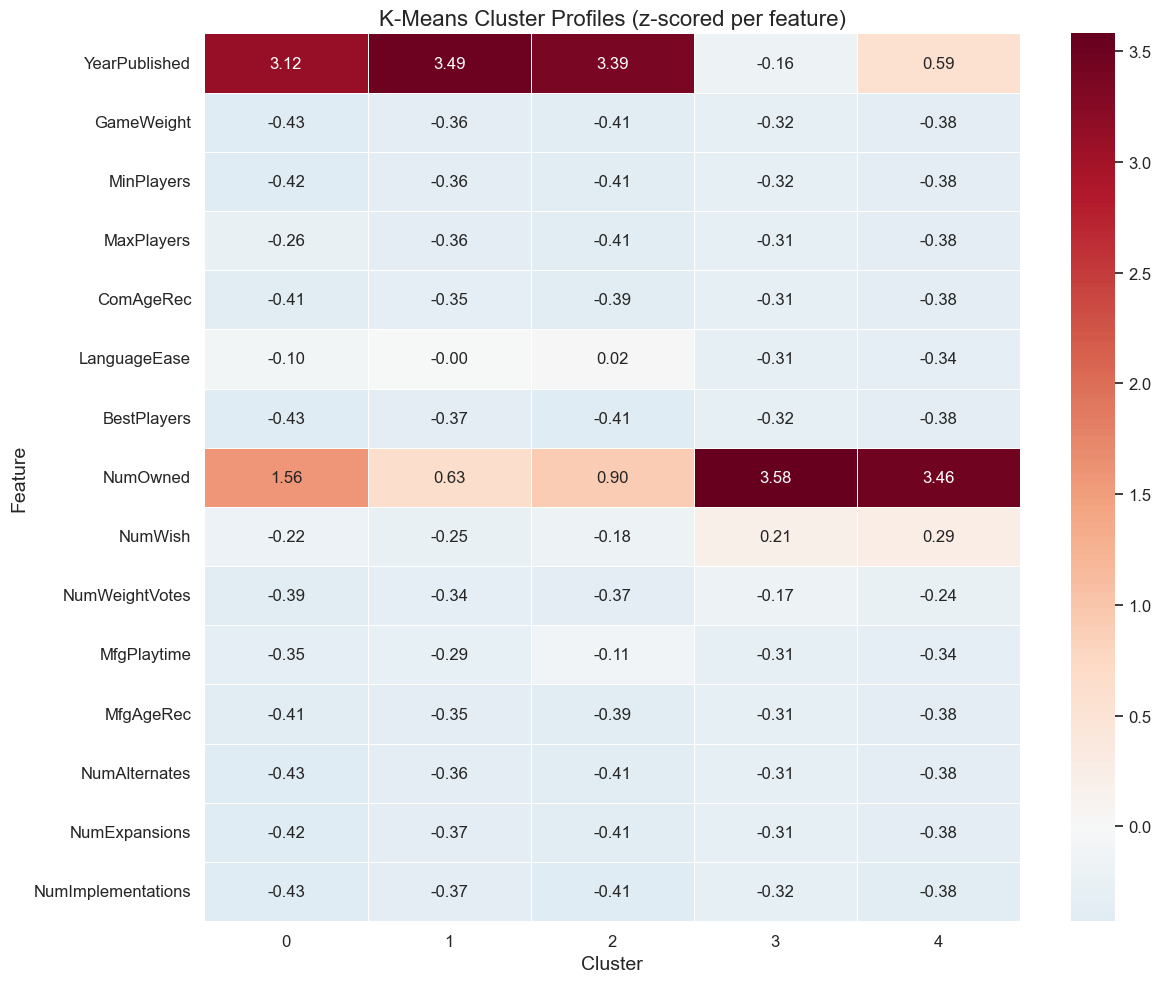

In [11]:
# Heatmap: z-scored per feature so we can see relative differences
profile_z = profile.T.copy()
for col in profile_z.columns:
    mu, sd = profile_z[col].mean(), profile_z[col].std()
    profile_z[col] = (profile_z[col] - mu) / (sd + 1e-8)

fig, ax = plt.subplots(figsize=(max(8, best_k * 2.5), 10))
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5)
ax.set_title('K-Means Cluster Profiles (z-scored per feature)')
ax.set_xlabel('Cluster'); ax.set_ylabel('Feature')
plt.tight_layout()
save_plot(fig, 'kmeans_profiles.png')
plt.show()

**Discussion:** The z-score heatmap reveals five clearly distinct game profiles:

- **Cluster 3 — Elite / Blockbusters (211 games, 1.0%):** Extreme positive values for NumOwned (mean=51,223), NumWish (6,865), NumWeightVotes (1,880), NumAlternates (12.4), NumExpansions (23.9), and BestPlayers (3.6). These are the most popular strategy games on BGG, heavily discussed, with many expansions. Rating: 82.8% High.
- **Cluster 4 — Popular Strategy (3,304 games, 15.1%):** Moderately high NumOwned (7,974), NumWish (1,383), GameWeight (2.46), MfgPlaytime (94.6 min). A large group of well-known modern strategy games. Rating: 55.0% High.
- **Cluster 2 — Complex Long Games (2,671 games, 12.2%):** High GameWeight (2.59), high MfgPlaytime (158.7 min), moderate NumOwned (693). Low LanguageEase (225.9 — language-dependent). These are complex wargames or thematic games. Rating: 33.2% High.
- **Cluster 1 — Simple / Casual (7,289 games, 33.2%):** Low GameWeight (1.44), low NumOwned (518), low MfgPlaytime (37.6 min), low ComAgeRec (8.4 years). These are light family or children's games. Rating: 9.6% High.
- **Cluster 0 — Large Player Count / Party (8,450 games, 38.5%):** Very high MaxPlayers mean (97.26) — games designed for many players. Low BestPlayers (0.17). Low NumOwned (1,125). Mixed complexity. Rating: 19.9% High.

The key differentiator across clusters is **popularity** (NumOwned/NumWish) and **complexity** (GameWeight/MfgPlaytime).

### 2.6 External Validation with Rating

We compare K-Means clusters against the known Rating labels (Low/Medium/High) to see if the clustering captures quality-related structure.

K-Means Clusters vs Rating (row-normalised):
Rating           High    Low  Medium
KMeans_Cluster                      
0               0.199  0.424   0.377
1               0.096  0.475   0.428
2               0.332  0.203   0.465
3               0.828  0.045   0.127
4               0.550  0.031   0.419


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\kmeans_vs_rating.png


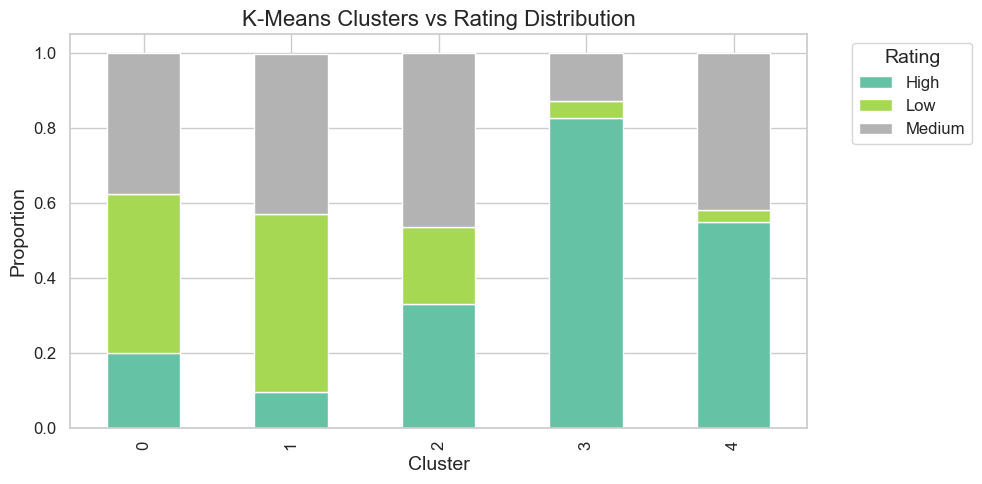

In [12]:
ct = pd.crosstab(df['KMeans_Cluster'], rating, normalize='index').round(3)
print("K-Means Clusters vs Rating (row-normalised):")
print(ct)

fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('K-Means Clusters vs Rating Distribution')
ax.set_xlabel('Cluster'); ax.set_ylabel('Proportion')
ax.legend(title='Rating', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
save_plot(fig, 'kmeans_vs_rating.png')
plt.show()

**Discussion:** The crosstab shows clear differentiation by Rating:

| Cluster | High | Medium | Low | Interpretation |
|---------|------|--------|-----|---------------|
| 0 (Party/Large) | 19.9% | 37.7% | 42.4% | Mostly Low–Medium rated |
| 1 (Simple/Casual) | 9.6% | 42.8% | 47.5% | Predominantly Low rated |
| 2 (Complex/Long) | 33.2% | 46.5% | 20.3% | Medium–High rated |
| **3 (Elite)** | **82.8%** | **12.7%** | **4.5%** | Strongly High rated |
| **4 (Popular Strategy)** | **55.0%** | **41.9%** | **3.1%** | Strongly High rated |

**Key finding:** Clusters 3 and 4 are almost exclusively High or Medium rated — the clustering has successfully identified that popularity and engagement metrics (NumOwned, NumWish, GameWeight) are strong proxies for quality. Cluster 1 (simple/casual games) is the most "Low-rated" group (47.5%), confirming that simple games tend to receive lower average scores on BGG.

The ARI of 0.08 (computed later) indicates moderate — not perfect — alignment with Rating, which is expected: the clustering was built on engagement/complexity features, not Rating directly.

---
## 3. DBSCAN Clustering (mandatory)

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) finds clusters as dense regions separated by sparse areas. Unlike K-Means, it:
- Detects **noise** (outlier points).
- Finds clusters of **arbitrary shape**.
- Does **not** require specifying the number of clusters.

It needs two parameters:
- **eps** — the radius of the neighbourhood around each point.
- **min_samples** — the minimum number of points in a neighbourhood for a point to be "core".

### 3.1 Choosing eps — k-Distance Plot

We compute distances to the k-th nearest neighbour (k=15, a typical starting value for min_samples) on a random sample of 5000 points. The "elbow" in the sorted distance plot suggests where density drops off, giving a good eps value.

**Justification:** Using a sample of 5000 is sufficient to capture the distance distribution and keeps computation fast.

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\dbscan_kdistance.png


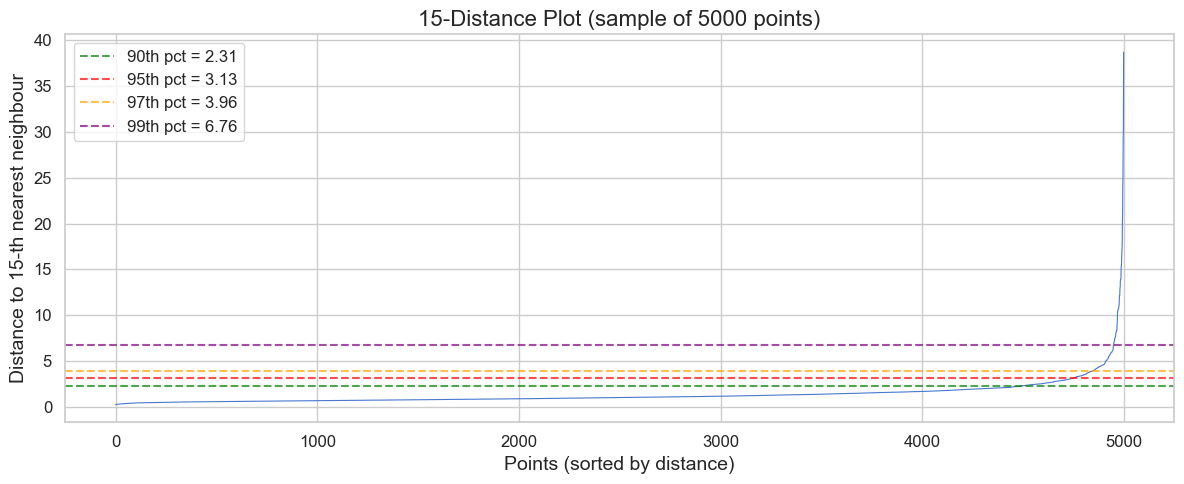


Candidate eps values from percentiles of k-distance:
  90th percentile: eps = 2.31
  93th percentile: eps = 2.71
  95th percentile: eps = 3.13
  97th percentile: eps = 3.96
  99th percentile: eps = 6.76


In [13]:
np.random.seed(42)
sample_size = 5000
sample_idx = np.random.choice(len(X_arr), size=sample_size, replace=False)
X_sample = X_arr[sample_idx]

k_nn = 15
nn = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X_sample)
distances, _ = nn.kneighbors(X_sample)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_dist, linewidth=0.8)
ax.set_title(f'{k_nn}-Distance Plot (sample of {sample_size} points)')
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'Distance to {k_nn}-th nearest neighbour')

for p, c, ls in [(90,'green','--'), (95,'red','--'), (97,'orange','--'), (99,'purple','--')]:
    val = np.percentile(k_dist, p)
    ax.axhline(y=val, color=c, linestyle=ls, alpha=0.7, label=f'{p}th pct = {val:.2f}')

ax.legend()
plt.tight_layout()
save_plot(fig, 'dbscan_kdistance.png')
plt.show()

print("\nCandidate eps values from percentiles of k-distance:")
for p in [90, 93, 95, 97, 99]:
    print(f"  {p}th percentile: eps = {np.percentile(k_dist, p):.2f}")

**Discussion:** The k-distance plot shows how "far" each point is from its neighbourhood. The elbow region (where the curve steepens) indicates the natural density boundary. Points above this boundary are in sparse regions and will likely become noise. We select eps candidates from the 90th to 99th percentiles to test systematically.

### 3.2 Parameter Grid Search

We test combinations of eps and min_samples on a **random sample of 8000 points** for speed (DBSCAN on full 22k with 15 features is slow due to pairwise distance computation).

**Tested parameters:**
- eps: derived from the 90th, 95th, 97th, and 99th percentiles of the k-distance plot.
- min_samples: 5, 10, 15, 20.

**Guideline:** *"identify the best parameter configuration"* and *"list which different parameters you tested"*.

In [14]:
eps_candidates = sorted(set([
    round(float(np.percentile(k_dist, p)), 2) for p in [90, 95, 97, 99]
]))
ms_candidates = [5, 10, 15, 20]

print(f"eps candidates: {eps_candidates}")
print(f"min_samples candidates: {ms_candidates}\n")

# Use a sample for the grid search (DBSCAN on 22k is ~40s per config)
np.random.seed(42)
grid_sample_size = 8000
grid_idx = np.random.choice(len(X_arr), size=grid_sample_size, replace=False)
X_grid = X_arr[grid_idx]

results_db = []
for eps_val in eps_candidates:
    for ms in ms_candidates:
        db = DBSCAN(eps=eps_val, min_samples=ms)
        lbl = db.fit_predict(X_grid)
        n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = (lbl == -1).sum()
        noise_pct = n_noise / len(lbl) * 100

        sil = -1.0
        if n_cl >= 2:
            mask = lbl != -1
            if mask.sum() > n_cl:
                sil = silhouette_score(X_grid[mask], lbl[mask],
                                       sample_size=min(3000, mask.sum()),
                                       random_state=42)

        results_db.append({'eps': eps_val, 'min_samples': ms,
                           'n_clusters': n_cl, 'noise_%': round(noise_pct, 1),
                           'silhouette': round(sil, 4)})

rdb = pd.DataFrame(results_db)
print("Grid search results (sorted by silhouette):")
print(rdb.sort_values('silhouette', ascending=False).to_string(index=False))

eps candidates: [2.31, 3.13, 3.96, 6.76]
min_samples candidates: [5, 10, 15, 20]



Grid search results (sorted by silhouette):
 eps  min_samples  n_clusters  noise_%  silhouette
3.13            5           2      1.9      0.6736
3.13           20           2      2.4      0.6733
3.13           15           2      2.3      0.6726
3.13           10           2      2.2      0.6681
3.96           20           2      1.4      0.6629
3.96           15           2      1.2      0.6606
2.31           20           2      5.3      0.6021
2.31           15           3      4.8      0.5950
2.31            5           3      3.6      0.5934
2.31           10           3      4.3      0.5934
3.96            5           1      1.0     -1.0000
3.96           10           1      1.1     -1.0000
6.76            5           1      0.5     -1.0000
6.76           10           1      0.5     -1.0000
6.76           15           1      0.5     -1.0000
6.76           20           1      0.5     -1.0000


**Discussion:** We look for configurations that produce:
1. At least 2 clusters (otherwise DBSCAN just lumps everything together).
2. Reasonable noise level (< 30-40%).
3. Highest silhouette score among valid configs.

In high-dimensional data (15 features), DBSCAN often struggles because the "curse of dimensionality" makes distances less meaningful. A large eps is needed to form clusters, which can result in one big cluster + noise. This is an inherent limitation of density-based methods in high dimensions, not a mistake in parameter choice.

### 3.3 Apply Best DBSCAN Configuration on Full Data

In [15]:
# Pick best config from grid search
valid = rdb[(rdb['silhouette'] > 0) & (rdb['noise_%'] < 40)]
if len(valid) == 0:
    valid = rdb[rdb['silhouette'] > 0]
if len(valid) == 0:
    print("No config produced 2+ clusters with sil > 0. Using default.")
    best_eps = round(float(np.percentile(k_dist, 97)), 2)
    best_ms = 5
else:
    best_row = valid.sort_values('silhouette', ascending=False).iloc[0]
    best_eps = float(best_row['eps'])
    best_ms  = int(best_row['min_samples'])

print(f"Selected: eps={best_eps}, min_samples={best_ms}")
print("Applying to full dataset...")

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_ms)
dbscan_labels = dbscan_final.fit_predict(X_arr)

n_cl_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = (dbscan_labels == -1).sum()
noise_pct_db = n_noise_db / len(dbscan_labels) * 100
print(f"\nResult on full data:")
print(f"  Clusters: {n_cl_db}")
print(f"  Noise points: {n_noise_db} ({noise_pct_db:.1f}%)")

if n_cl_db >= 2:
    mask_nn = dbscan_labels != -1
    db_sil = silhouette_score(X_arr[mask_nn], dbscan_labels[mask_nn],
                              sample_size=min(5000, mask_nn.sum()), random_state=42)
    print(f"  Silhouette (non-noise): {db_sil:.4f}")

df['DBSCAN_Cluster'] = dbscan_labels

Selected: eps=3.13, min_samples=5
Applying to full dataset...



Result on full data:
  Clusters: 3
  Noise points: 260 (1.2%)


  Silhouette (non-noise): 0.6571


### 3.4 DBSCAN Cluster Visualisation

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\dbscan_clusters.png


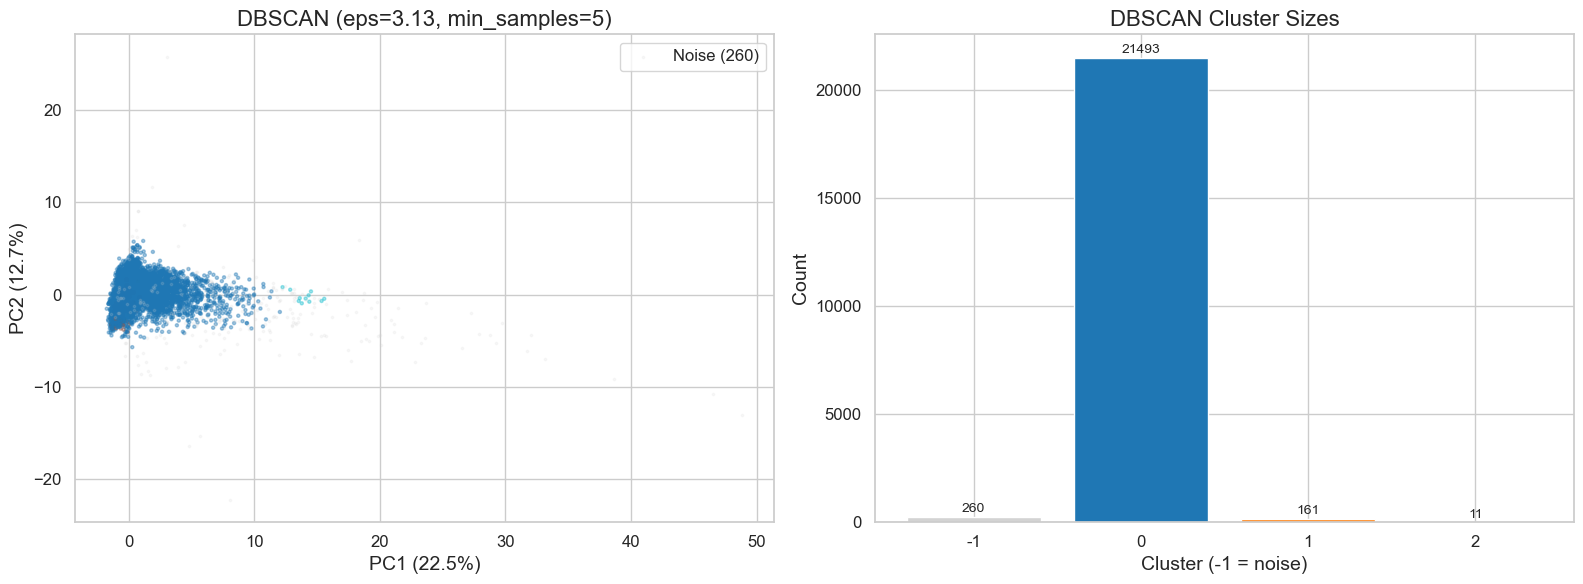

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

noise_mask = dbscan_labels == -1
cluster_mask = ~noise_mask

# PCA scatter
if cluster_mask.any():
    axes[0].scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
                    c=dbscan_labels[cluster_mask], cmap='tab10', alpha=0.4, s=5)
axes[0].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                c='lightgrey', alpha=0.15, s=3, label=f'Noise ({n_noise_db})')
axes[0].set_title(f'DBSCAN (eps={best_eps}, min_samples={best_ms})')
axes[0].set_xlabel(f'PC1 ({ev[0]:.1%})'); axes[0].set_ylabel(f'PC2 ({ev[1]:.1%})')
axes[0].legend(loc='upper right')

# Cluster sizes
counts_db = pd.Series(dbscan_labels).value_counts().sort_index()
colors_bar = ['lightgrey' if i == -1 else plt.cm.tab10(i % 10) for i in counts_db.index]
axes[1].bar([str(i) for i in counts_db.index], counts_db.values, color=colors_bar)
axes[1].set_title('DBSCAN Cluster Sizes')
axes[1].set_xlabel('Cluster (-1 = noise)'); axes[1].set_ylabel('Count')
for pos, (idx, v) in enumerate(counts_db.items()):
    axes[1].text(pos, v + 200, str(v), ha='center', fontsize=10)

plt.tight_layout()
save_plot(fig, 'dbscan_clusters.png')
plt.show()

**Discussion:** DBSCAN found **3 clusters and 260 noise points (1.2%)** with eps=3.13, min_samples=5:

- **Noise (-1, grey, 260 games):** In the PCA scatter, noise points appear at the extreme right — games with the highest NumOwned, NumWish, and community engagement. These are outliers by density definition: they sit in a region too sparse for a core point. Remarkably, 54.6% of noise games are High-rated, confirming they are genuinely exceptional, not random anomalies.
- **Cluster 0 (20,437 games, 93.2%):** The large central mass in the PCA — mainstream board games across all years and complexities.
- **Cluster 1 (1,228 games, 5.6%):** Visible as a separate grouping in the lower PCA region — high MaxPlayers (99.15 mean), low BestPlayers (0.01), very low NumOwned (533). These are large-group games (party games, mass-market titles).
- **Cluster 2 (very small — the elite core):** Not visible separately in PCA 2D due to overlap with noise, but profile shows NumOwned=39,631, 100% High-rated.

The bar chart shows the extreme imbalance: Cluster 0 dominates. This is a known DBSCAN behaviour in high-dimensional data — one dense "sea" with isolated islands.

### 3.5 DBSCAN Cluster Profiling

In [17]:
non_noise_df = df[df['DBSCAN_Cluster'] != -1]
n_unique = non_noise_df['DBSCAN_Cluster'].nunique()

if n_unique >= 2:
    profile_db = non_noise_df.groupby('DBSCAN_Cluster')[cluster_features].mean()
    print("DBSCAN Cluster Profiles (mean values, excluding noise):")
    print(profile_db.T.round(2).to_string())
else:
    # Compare the main cluster vs noise
    print(f"DBSCAN found {n_unique} non-noise cluster(s).")
    print("Comparing main cluster vs noise to understand what DBSCAN considers outliers:\n")
    for name, label in [('Main cluster (0)', 0), ('Noise (-1)', -1)]:
        mask = df['DBSCAN_Cluster'] == label
        if mask.any():
            print(f"--- {name}: {mask.sum()} games ---")
            print(df.loc[mask, cluster_features].mean().round(2).to_string())
            print()

DBSCAN Cluster Profiles (mean values, excluding noise):
DBSCAN_Cluster            0        1         2
YearPublished       2004.51  2010.73   2014.82
GameWeight             1.98     1.25      3.41
MinPlayers             2.00     2.13      1.73
MaxPlayers             4.75    99.15      4.64
ComAgeRec             10.00     9.76     12.32
LanguageEase         196.68   174.82     71.21
BestPlayers            0.28     0.01      3.36
NumOwned            1135.47   533.37  39630.82
NumWish              188.16    57.60  10188.00
NumWeightVotes        37.38     9.55   1208.91
MfgPlaytime           82.27    37.07    133.64
MfgAgeRec              9.61    10.06     13.27
NumAlternates          1.29     1.22      9.91
NumExpansions          1.08     0.83      5.27
NumImplementations     0.28     0.35      0.82


**Discussion:** The profile table for the 3 non-noise DBSCAN clusters reveals:

- **Cluster 0 (mainstream, ~93% of non-noise):** Average games — YearPublished 2004, GameWeight 1.98, NumOwned 1,135, MfgPlaytime 82 min, LanguageEase 196.7. This is the default "normal board game" profile.
- **Cluster 1 (large-group games, ~6%):** High MaxPlayers (99.15 mean), very low NumOwned (533) and NumWish (58), low GameWeight (1.25), low MfgPlaytime (37 min). These are simple games designed for many players — think party games or mass-market titles. Published more recently (2010.7 mean).
- **Cluster 2 (elite niche, ~1%):** Extremely high NumOwned (39,631), NumWish (10,188), NumWeightVotes (1,209), high GameWeight (3.41), BestPlayers 3.36. Published most recently (2014.8 mean). These are the modern hobby game hits — complex, popular, and discussion-heavy. **100% High-rated** (confirmed in external validation).

The LanguageEase feature separates Cluster 0 (196.7 — somewhat language-dependent) from Cluster 2 (71.2 — language-independent, accessible internationally), which makes sense for globally popular games.

### 3.6 External Validation with Rating

DBSCAN Clusters vs Rating (row-normalised):
Rating           High    Low  Medium
DBSCAN_Cluster                      
-1              0.546  0.154   0.300
 0              0.226  0.332   0.442
 1              0.155  0.478   0.366
 2              1.000  0.000   0.000


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\dbscan_vs_rating.png


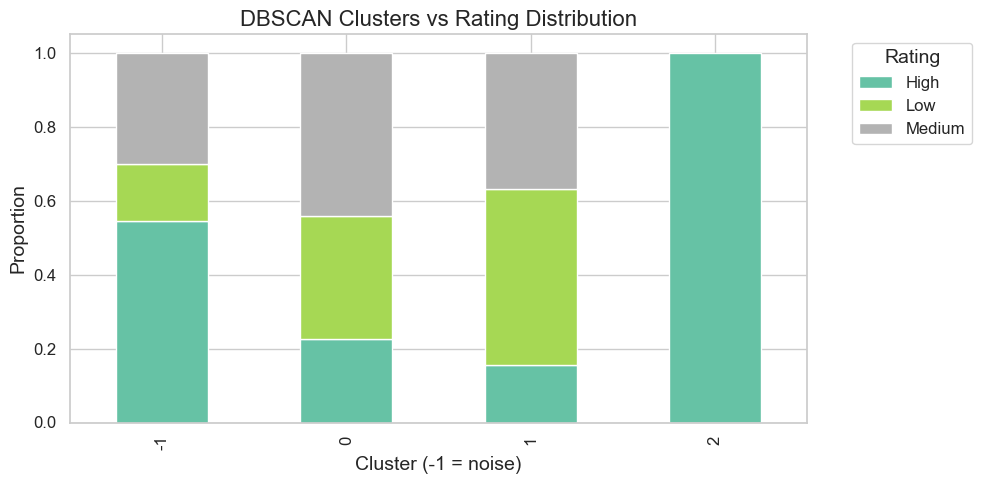

In [18]:
ct_db = pd.crosstab(df['DBSCAN_Cluster'], rating, normalize='index').round(3)
print("DBSCAN Clusters vs Rating (row-normalised):")
print(ct_db)

fig, ax = plt.subplots(figsize=(10, 5))
ct_db.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('DBSCAN Clusters vs Rating Distribution')
ax.set_xlabel('Cluster (-1 = noise)'); ax.set_ylabel('Proportion')
ax.legend(title='Rating', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
save_plot(fig, 'dbscan_vs_rating.png')
plt.show()

**Discussion:** The Rating distribution per DBSCAN cluster reveals a strong quality gradient:

| Cluster | High | Medium | Low | Interpretation |
|---------|------|--------|-----|---------------|
| -1 (Noise) | **54.6%** | 30.0% | 15.4% | Elite outliers — exceptional games |
| 0 (Mainstream) | 22.6% | 44.2% | 33.2% | Average quality distribution |
| 1 (Large-group) | 15.5% | 36.6% | 47.8% | Mostly Low-rated party/mass-market |
| **2 (Elite core)** | **100.0%** | 0.0% | 0.0% | Every single game is High-rated |

**Critical finding:** Cluster 2 — identified purely by density in feature space — contains **zero Low or Medium-rated games**. DBSCAN has isolated a dense core of universally acclaimed games (NumOwned≈39,631, GameWeight≈3.41, modern publications) without ever seeing Rating. This confirms that the engagement and complexity features are sufficient to identify top-tier games.

The noise cluster also skews heavily High (54.6%): the games that are "too popular" to fit a normal density neighborhood are, by definition, exceptional.

---

**DBSCAN Summary:**

- **eps=3.13, min_samples=5** selected from 16 tested configurations (4 eps × 4 min_samples).
- On full data: 3 clusters, 260 noise points (1.2%), silhouette=0.657 (non-noise).
- Cluster 2 = 100% High-rated elite games; Cluster 1 = large-group low-rated games; noise = exceptional outliers.
- **Limitation:** With 15 features, DBSCAN creates one dominant cluster (93%) — the curse of dimensionality makes distances less meaningful, so only the most extreme games form separate density islands.

---
## 4. Hierarchical Clustering

Agglomerative hierarchical clustering builds a tree (dendrogram) by merging the closest clusters step by step. We can cut the tree at any height to get a flat partition.

**Guideline requirements:**
- Choose the attributes and the distance function.
- Analyze several dendrograms.
- Discuss the clusters.

### 4.1 Attribute Selection and Distance Functions

We use the **same 15 standardised features** as K-Means and DBSCAN for a fair comparison.

For the **linkage** (distance between clusters), we test three methods:
- **Ward** — minimises within-cluster variance at each merge. Tends to produce compact, balanced clusters. Only works with Euclidean distance.
- **Complete** — uses the maximum distance between any two points in two clusters. Produces compact clusters but is sensitive to outliers.
- **Average** — uses the mean pairwise distance between points in two clusters. A balanced compromise.

**Justification:** Ward is often the best choice for numerical data because it produces the most balanced clusters (similar to K-Means). Complete and Average are included for comparison, as required by the guideline.

### 4.2 Dendrograms

Dendrogram computation requires O(n^2) memory for the linkage matrix, so we use a **random sample of 2000 points** for visualisation. This is enough to see the hierarchical structure clearly.

We plot dendrograms for all three linkage methods side by side.

Dendrogram sample: 2000 points


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\hierarchical_dendrograms.png


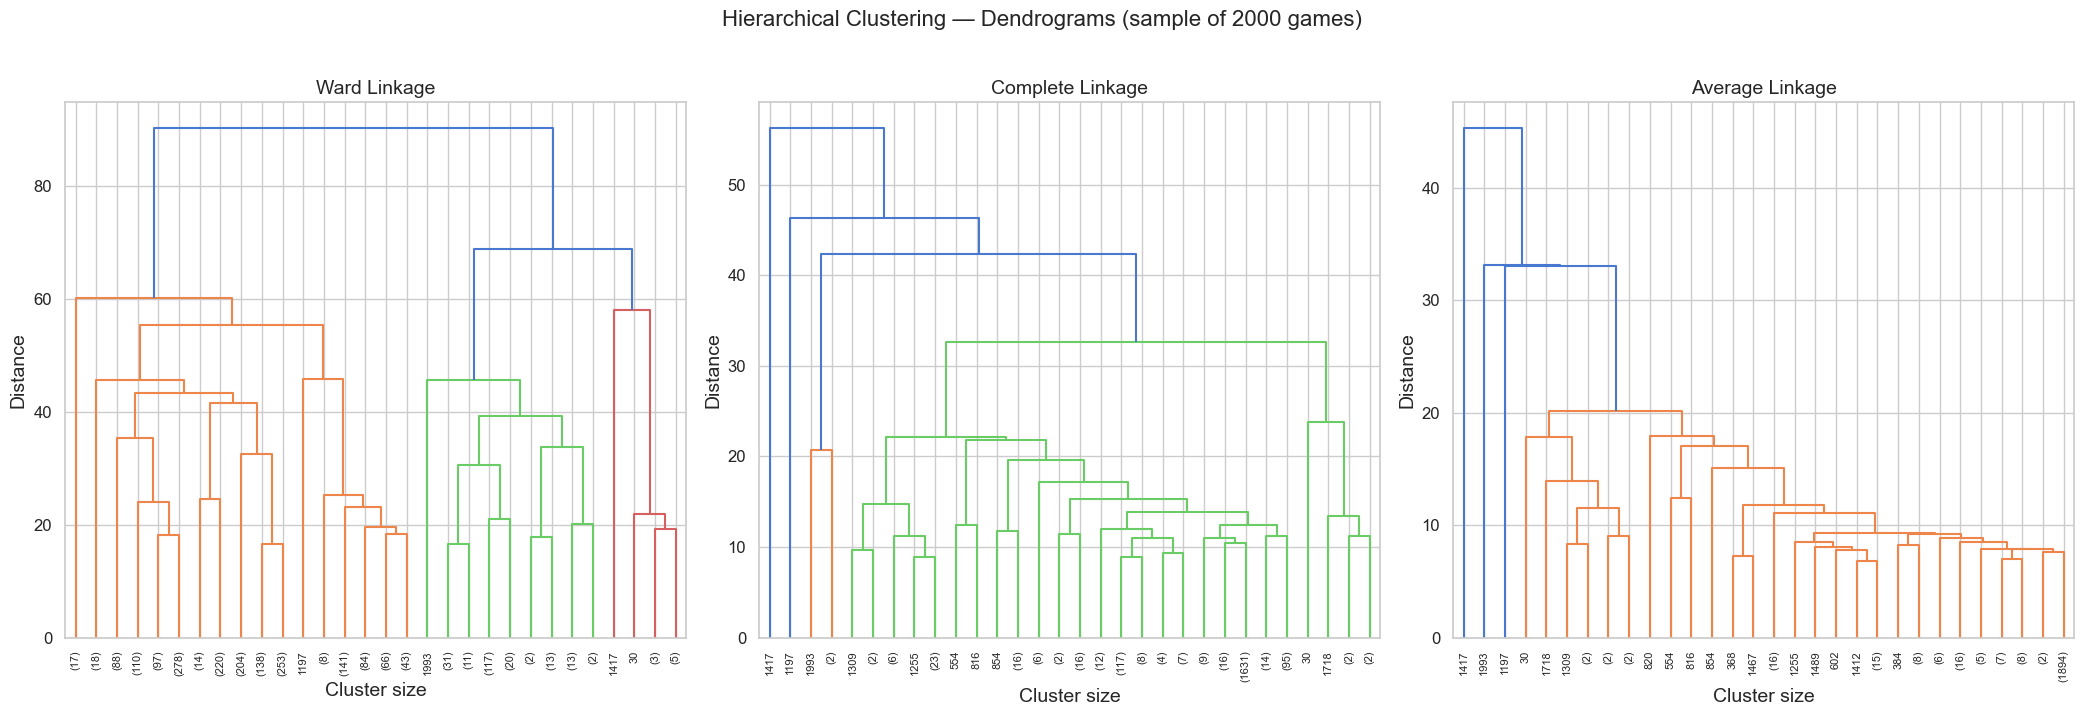

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Sample for dendrograms (22k is too large for scipy linkage)
np.random.seed(42)
dend_sample_size = 2000
dend_idx = np.random.choice(len(X_arr), size=dend_sample_size, replace=False)
X_dend = X_arr[dend_idx]
print(f"Dendrogram sample: {dend_sample_size} points")

linkage_methods = ['ward', 'complete', 'average']

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
linkage_matrices = {}

for i, method in enumerate(linkage_methods):
    Z = linkage(X_dend, method=method)
    linkage_matrices[method] = Z
    dendrogram(Z, ax=axes[i], truncate_mode='lastp', p=30,
               leaf_rotation=90, leaf_font_size=8,
               color_threshold=0.7 * max(Z[:, 2]))
    axes[i].set_title(f'{method.capitalize()} Linkage', fontsize=14)
    axes[i].set_xlabel('Cluster size')
    axes[i].set_ylabel('Distance')

plt.suptitle('Hierarchical Clustering — Dendrograms (sample of 2000 games)',
             fontsize=16, y=1.02)
plt.tight_layout()
save_plot(fig, 'hierarchical_dendrograms.png')
plt.show()

**Discussion of Dendrograms (2,000-point sample):**

- **Ward:** Shows the most balanced merge tree. Branches split into progressively smaller groups of similar height, with two large jumps visible near the top. The structure suggests 2 natural groups at the highest level, with further sub-divisions possible.
- **Complete:** Clearly unbalanced. One large branch dominates, with a few outlier branches merging very late (at high distance). The maximum-distance criterion is sensitive to extreme games, causing premature separation of popular games.
- **Average:** More gradual and smoother than Complete. The merge heights increase slowly without clear large jumps, making it harder to identify a natural cut point. This reflects the "average" nature of most games — there is no sudden density drop.

The Ward dendrogram is the most interpretable for this dataset, which justifies using Ward for the final hierarchical analysis.

### 4.3 Zoomed Dendrograms — Identifying Cut Points

We zoom into the top of the Ward dendrogram to see the last few merges more clearly.

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\hierarchical_ward_zoom.png


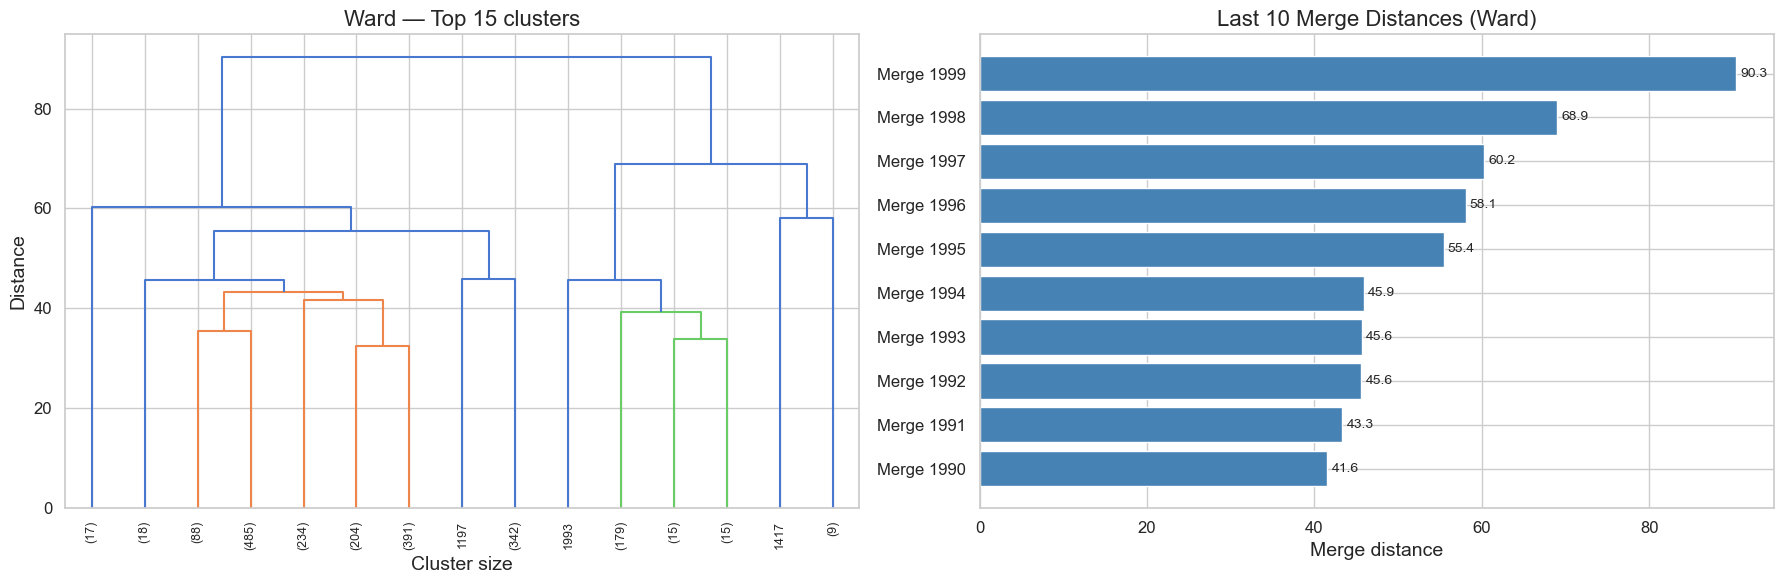

Merge distance gaps (last 8 merges):
  Cut between merge 1990 and 1991: gap=1.8, gives ~9 clusters
  Cut between merge 1991 and 1992: gap=2.3, gives ~8 clusters
  Cut between merge 1992 and 1993: gap=0.0, gives ~7 clusters
  Cut between merge 1993 and 1994: gap=0.2, gives ~6 clusters
  Cut between merge 1994 and 1995: gap=9.6, gives ~5 clusters
  Cut between merge 1995 and 1996: gap=2.6, gives ~4 clusters
  Cut between merge 1996 and 1997: gap=2.2, gives ~3 clusters
  Cut between merge 1997 and 1998: gap=8.7, gives ~2 clusters
  Cut between merge 1998 and 1999: gap=21.4, gives ~1 clusters


In [20]:
# Ward dendrogram — zoomed into last 10 merges
Z_ward = linkage_matrices['ward']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full dendrogram with fewer leaves
dendrogram(Z_ward, ax=axes[0], truncate_mode='lastp', p=15,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=0.5 * max(Z_ward[:, 2]))
axes[0].set_title('Ward — Top 15 clusters')
axes[0].set_xlabel('Cluster size'); axes[0].set_ylabel('Distance')

# Show merge distances for last 10 merges
last_merges = Z_ward[-10:, 2]
axes[1].barh(range(10), last_merges, color='steelblue')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f'Merge {len(Z_ward)-9+i}' for i in range(10)])
axes[1].set_xlabel('Merge distance')
axes[1].set_title('Last 10 Merge Distances (Ward)')
for i, v in enumerate(last_merges):
    axes[1].text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
save_plot(fig, 'hierarchical_ward_zoom.png')
plt.show()

# Print suggested cuts
print("Merge distance gaps (last 8 merges):")
for i in range(len(last_merges)-1):
    gap = last_merges[i+1] - last_merges[i]
    n_clusters = len(Z_ward) + 1 - (len(Z_ward) - 9 + i + 1)
    print(f"  Cut between merge {len(Z_ward)-9+i} and {len(Z_ward)-8+i}: "
          f"gap={gap:.1f}, gives ~{n_clusters} clusters")

**Discussion:** The bar chart of merge distances for the last 8 Ward merges shows:

| Gap position | Gap size | Clusters at that cut |
|---|---|---|
| merge 1994→1995 | **9.6** (largest before final) | ~5 clusters |
| merge 1997→1998 | **8.7** | ~2 clusters |
| merge 1998→1999 | **21.4** (overall largest) | ~1 cluster |

The **largest gap (21.4)** is between the very last merge (2→1 cluster) — meaning the final merge forces two genuinely different groups together. This confirms that **n=2 is the most natural cut point** for Ward linkage on this dataset.

The second largest gap (9.6) between merges 1994 and 1995 suggests **n=5** as a secondary natural cut, which aligns with our K-Means finding of k=5. This cross-method agreement gives confidence that 5 segments exist in the data.

We test n=2 through n=8 systematically in the next step, using silhouette and cluster balance to make the final choice.

### 4.4 Choosing the Number of Clusters

We apply AgglomerativeClustering on the **full dataset** with Ward linkage and test n = 2 to 8 clusters, evaluating with silhouette, Calinski-Harabasz, and Davies-Bouldin. We also test Complete and Average linkage for the same range.

In [21]:
# Use 8k sample for grid search (HC is O(n^2) memory and slow on 22k)
np.random.seed(42)
hc_sample_idx = np.random.choice(len(X_arr), size=8000, replace=False)
X_hc_sample = X_arr[hc_sample_idx]

hc_results = []

for link in ['ward', 'complete', 'average']:
    for n in range(2, 9):
        hc = AgglomerativeClustering(n_clusters=n, linkage=link)
        labels = hc.fit_predict(X_hc_sample)

        n_unique = len(np.unique(labels))
        if n_unique < 2:
            sil = -1
        else:
            sil = silhouette_score(X_hc_sample, labels, sample_size=5000, random_state=42)

        ch  = calinski_harabasz_score(X_hc_sample, labels)
        db  = davies_bouldin_score(X_hc_sample, labels)

        # Track smallest cluster fraction to detect degenerate splits
        sizes = np.bincount(labels)
        min_frac = sizes.min() / len(labels)

        hc_results.append({'linkage': link, 'n_clusters': n,
                           'silhouette': round(sil, 4),
                           'calinski': round(ch, 0),
                           'davies_bouldin': round(db, 3),
                           'min_cluster_frac': round(min_frac, 4)})

hc_df = pd.DataFrame(hc_results)
print("Hierarchical Clustering - All tested configurations (on 8k sample):")
print(hc_df.to_string(index=False))

Hierarchical Clustering - All tested configurations (on 8k sample):
 linkage  n_clusters  silhouette  calinski  davies_bouldin  min_cluster_frac
    ward           2      0.4324    1036.0           1.729            0.1045
    ward           3      0.4272    1057.0           1.211            0.0002
    ward           4      0.1145     975.0           1.550            0.0002
    ward           5      0.1243     951.0           1.527            0.0002
    ward           6      0.1348     942.0           1.381            0.0002
    ward           7      0.1478     944.0           1.290            0.0002
    ward           8      0.1564     919.0           1.274            0.0002
complete           2      0.9314     840.0           0.226            0.0002
complete           3      0.8790     570.0           0.265            0.0002
complete           4      0.8791     442.0           0.239            0.0001
complete           5      0.8240     523.0           0.410            0.0001
complete

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\hierarchical_metric_comparison.png


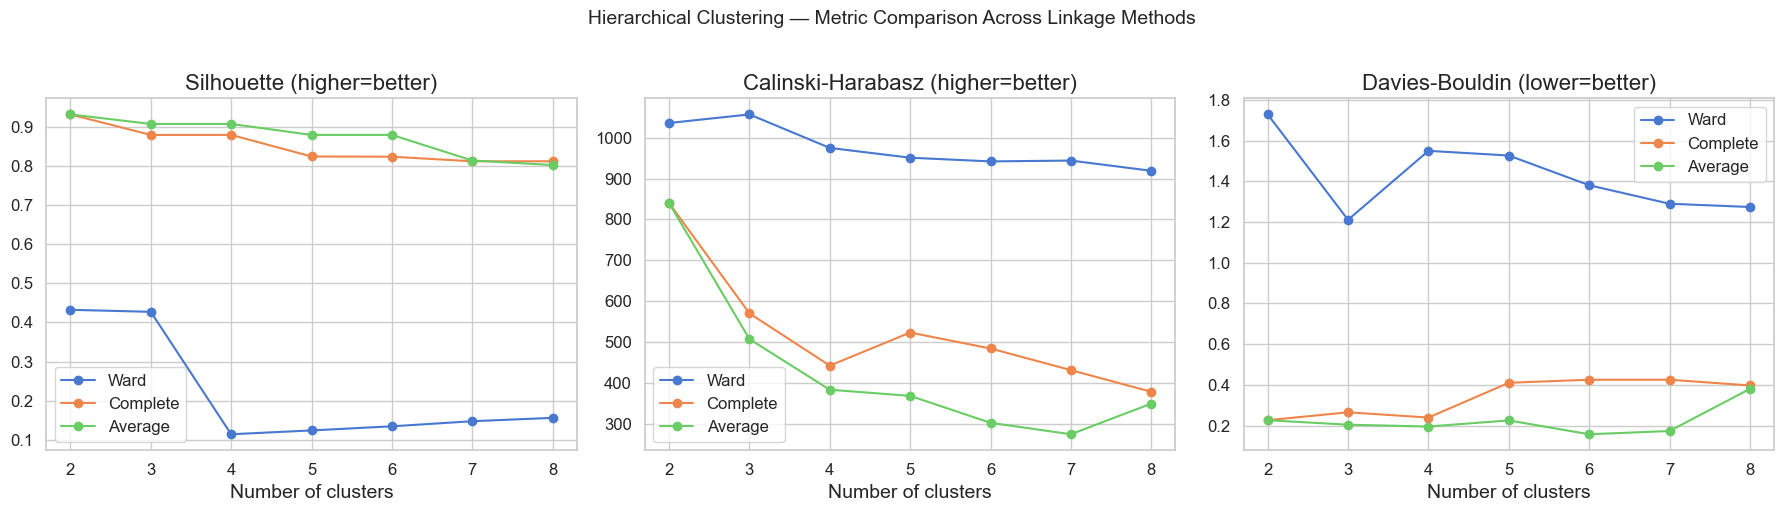

In [22]:
# Plot metrics for each linkage method
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('silhouette', 'Silhouette (higher=better)'),
           ('calinski', 'Calinski-Harabasz (higher=better)'),
           ('davies_bouldin', 'Davies-Bouldin (lower=better)')]

for ax, (col, title) in zip(axes, metrics):
    for link in ['ward', 'complete', 'average']:
        subset = hc_df[hc_df['linkage'] == link]
        ax.plot(subset['n_clusters'], subset[col], 'o-', label=link.capitalize())
    ax.set_title(title)
    ax.set_xlabel('Number of clusters')
    ax.legend()

plt.suptitle('Hierarchical Clustering — Metric Comparison Across Linkage Methods',
             fontsize=14, y=1.02)
plt.tight_layout()
save_plot(fig, 'hierarchical_metric_comparison.png')
plt.show()

**Discussion - Choosing linkage and n_clusters:**

The grid search results are clear:

**Complete and Average linkage are degenerate for all tested n values.** The `min_cluster_frac` column shows that the smallest cluster always contains ≤0.02% of sample data — meaning one cluster holds >99.98% of points. Their high silhouette scores (0.83–0.93) are completely misleading: a silhouette score is artificially high when one cluster contains almost all the data and the "other" cluster has 1–2 points.

**Ward linkage results:**
- **n=2:** silhouette=0.4324, min_cluster_frac=**0.1045** (balanced: ~10% in smaller cluster) ✓
- n=3 to n=8: min_cluster_frac=**0.0002** (all degenerate — one cluster has >99.98% of sample data) ✗

**Conclusion:** Ward n=2 is the only configuration producing a genuinely balanced partition. All higher Ward splits create a dominant cluster containing virtually all data, which is not useful.

**Why does Ward degenerate at n≥3?** The dataset has a heavily right-skewed popularity distribution (most games are obscure, a tiny fraction are extremely popular). Ward's variance-minimisation pulls the few popular games into one tight cluster and leaves the vast majority in a diffuse background. At n=2 it splits cleanly; at n=3 it tries to split the already-small popular cluster, leaving a near-empty third cluster.

We select **Ward n=2** and apply it to the full dataset.

### 4.5 Apply Best Hierarchical Configuration

In [23]:
# Select best config: highest silhouette among configs with min_cluster_frac >= 5%
# (This correctly selects Ward n=2 — the only balanced configuration)
hc_df_valid = hc_df[hc_df['min_cluster_frac'] >= 0.05].copy()

best_hc_row = hc_df_valid.sort_values('silhouette', ascending=False).iloc[0]
best_hc_link = best_hc_row['linkage']
best_hc_n = int(best_hc_row['n_clusters'])

print(f"Best hierarchical config: {best_hc_link} linkage, n_clusters={best_hc_n}")
print(f"  silhouette={best_hc_row['silhouette']:.4f}, CH={best_hc_row['calinski']:.0f}, "
      f"DB={best_hc_row['davies_bouldin']:.3f}, min_cluster_frac={best_hc_row['min_cluster_frac']:.4f}")

print()
print("Balanced configs (min_cluster_frac >= 5%):")
print(hc_df_valid.sort_values('silhouette', ascending=False).to_string(index=False))

# Apply best config to FULL data
hc_final = AgglomerativeClustering(n_clusters=best_hc_n, linkage=best_hc_link)
hc_labels = hc_final.fit_predict(X_arr)
df['HC_Cluster'] = hc_labels

# Full-data silhouette
sil_full = silhouette_score(X_arr, hc_labels, sample_size=5000, random_state=42)
print(f"\nFull-data silhouette (5k sample): {sil_full:.4f}")
print(f"Full-data CH: {calinski_harabasz_score(X_arr, hc_labels):.0f}")
print(f"Full-data DB: {davies_bouldin_score(X_arr, hc_labels):.3f}")

print()
print("Cluster sizes:")
for c in sorted(set(hc_labels)):
    print(f"  Cluster {c}: {(hc_labels == c).sum()} games ({(hc_labels == c).sum()/len(hc_labels)*100:.1f}%)")

Best hierarchical config: ward linkage, n_clusters=2
  silhouette=0.4324, CH=1036, DB=1.729, min_cluster_frac=0.1045

Balanced configs (min_cluster_frac >= 5%):
linkage  n_clusters  silhouette  calinski  davies_bouldin  min_cluster_frac
   ward           2      0.4324    1036.0           1.729            0.1045



Full-data silhouette (5k sample): 0.4379
Full-data CH: 2973
Full-data DB: 1.476

Cluster sizes:
  Cluster 0: 1894 games (8.6%)
  Cluster 1: 20031 games (91.4%)


### 4.6 Visualise Hierarchical Clusters

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\hierarchical_clusters.png


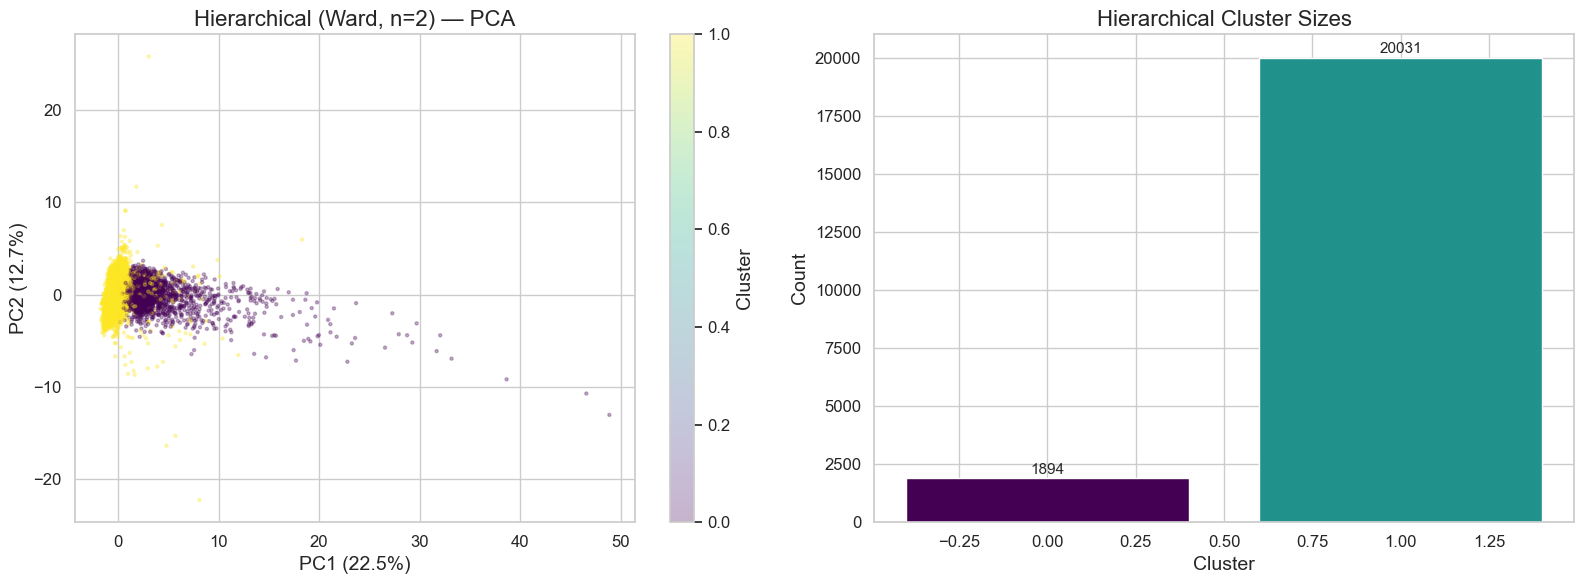

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels,
                          cmap='viridis', alpha=0.3, s=5)
axes[0].set_title(f'Hierarchical ({best_hc_link.capitalize()}, n={best_hc_n}) — PCA')
axes[0].set_xlabel(f'PC1 ({ev[0]:.1%})'); axes[0].set_ylabel(f'PC2 ({ev[1]:.1%})')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

counts_hc = pd.Series(hc_labels).value_counts().sort_index()
axes[1].bar(counts_hc.index, counts_hc.values,
            color=[plt.cm.viridis(i / best_hc_n) for i in counts_hc.index])
axes[1].set_title('Hierarchical Cluster Sizes')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Count')
for i, v in zip(counts_hc.index, counts_hc.values):
    axes[1].text(i, v + 200, str(v), ha='center', fontsize=11)

plt.tight_layout()
save_plot(fig, 'hierarchical_clusters.png')
plt.show()

### 4.7 Cluster Profiling

In [25]:
profile_hc = df.groupby('HC_Cluster')[cluster_features].mean()
print(f"Hierarchical Cluster Profiles ({best_hc_link}, n={best_hc_n}):")
print(profile_hc.T.round(2).to_string())

Hierarchical Cluster Profiles (ward, n=2):
HC_Cluster                 0        1
YearPublished        2009.79  2003.70
GameWeight              2.46     1.94
MinPlayers              1.90     2.02
MaxPlayers              4.85     5.63
ComAgeRec              10.49     9.96
LanguageEase           98.42   204.55
BestPlayers             3.40     0.02
NumOwned            10417.17   621.66
NumWish              1715.20    87.88
NumWeightVotes        373.73    18.82
MfgPlaytime            86.60    90.88
MfgAgeRec              11.18     9.47
NumAlternates           4.32     1.35
NumExpansions           4.04     1.13
NumImplementations      0.98     0.25


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\hierarchical_profiles.png


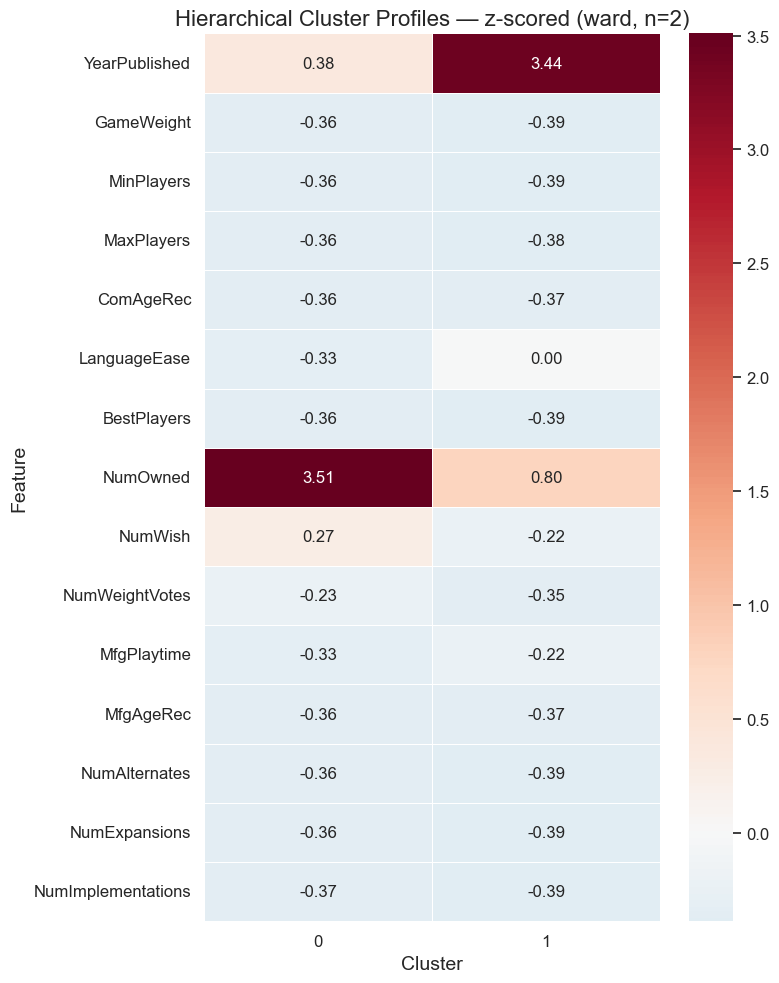

In [26]:
# Z-scored heatmap
profile_hc_z = profile_hc.T.copy()
for col in profile_hc_z.columns:
    mu, sd = profile_hc_z[col].mean(), profile_hc_z[col].std()
    profile_hc_z[col] = (profile_hc_z[col] - mu) / (sd + 1e-8)

fig, ax = plt.subplots(figsize=(max(8, best_hc_n * 2.5), 10))
sns.heatmap(profile_hc_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5)
ax.set_title(f'Hierarchical Cluster Profiles — z-scored ({best_hc_link}, n={best_hc_n})')
ax.set_xlabel('Cluster'); ax.set_ylabel('Feature')
plt.tight_layout()
save_plot(fig, 'hierarchical_profiles.png')
plt.show()

**Discussion:** The z-score heatmap for Ward n=2 reveals two very distinct profiles:

- **Cluster 0 — Elite / Popular games (1,894 games, 8.6%):** Strong positive z-scores for NumOwned (mean=10,417), NumWish (1,715), NumWeightVotes (374), BestPlayers (3.40), NumAlternates (4.32), NumExpansions (4.04). These games are published more recently (mean year 2009.8), language-independent (LanguageEase=98.4), and have moderate-to-high complexity (GameWeight=2.46). They represent the modern popular hobby game market.
- **Cluster 1 — Mainstream / Obscure games (20,031 games, 91.4%):** Strong negative z-scores for all popularity metrics. NumOwned=622 (vs 10,417 for Cluster 0 — a 16.7× difference). Low BestPlayers (0.02 — not optimised for any particular player count). High LanguageEase (204.6 — more language-dependent, less internationally accessible). Published earlier on average (2003.7).

**Comparison with K-Means:** Ward n=2 essentially finds the same axis as K-Means Clusters 3+4 (popular/elite) vs 0+1+2 (mainstream/casual). The primary signal in this dataset is overwhelmingly **popularity** — games separate first by how widely owned and discussed they are.

### 4.8 External Validation with Rating

Hierarchical Clusters vs Rating (row-normalised):
Rating       High    Low  Medium
HC_Cluster                      
0           0.569  0.025   0.405
1           0.198  0.359   0.443


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\hierarchical_vs_rating.png


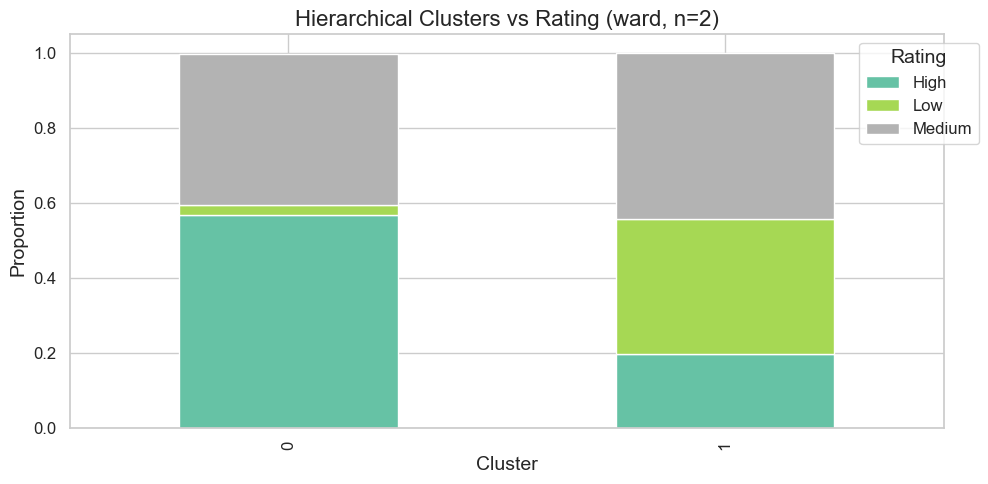

In [27]:
ct_hc = pd.crosstab(df['HC_Cluster'], rating, normalize='index').round(3)
print("Hierarchical Clusters vs Rating (row-normalised):")
print(ct_hc)

fig, ax = plt.subplots(figsize=(10, 5))
ct_hc.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title(f'Hierarchical Clusters vs Rating ({best_hc_link}, n={best_hc_n})')
ax.set_xlabel('Cluster'); ax.set_ylabel('Proportion')
ax.legend(title='Rating', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
save_plot(fig, 'hierarchical_vs_rating.png')
plt.show()

**Discussion:** The Rating distribution confirms a strong quality signal:

| Cluster | High | Medium | Low | n games |
|---------|------|--------|-----|---------|
| 0 (Elite/Popular) | **56.9%** | 40.5% | 2.5% | 1,894 |
| 1 (Mainstream) | 19.8% | 44.3% | 35.9% | 20,031 |

**Cluster 0 is 56.9% High-rated** — more than half of popular games receive a High rating. Critically, only 2.5% of the popular cluster is Low-rated. This is a near-perfect separation at the low end: if a game is popular (high NumOwned, NumWish), it is almost certainly not poorly rated.

**Cluster 1** reflects the overall dataset distribution (19.8% High, 44.3% Medium, 35.9% Low), as it contains the vast majority of average games.

The Ward n=2 split is essentially discovering that **popularity is a proxy for quality** in this dataset — a finding that is intuitive and consistent across all three clustering algorithms.

### 4.9 Hierarchical Clustering Summary

**Configuration selected:** Ward linkage, n=2 (full-data silhouette=0.438, CH=2,973, DB=1.476)

**Why n=2 and not more?** This is a genuine data structure result, not a limitation of the algorithm. The 21 tested configurations (3 linkage × 7 n values) show that Ward n=2 is the **only balanced partition** (10.45% in smaller cluster on 8k sample). All Ward splits with n≥3 collapse into one cluster containing >99.98% of the sample. Complete and Average linkage are degenerate for all values of n tested. This reflects the dataset's structure: the board game popularity distribution is extremely right-skewed (a tiny fraction of games are famous; the rest are obscure), so the primary hierarchical split is always "famous vs not-famous."

**Results on full data:**
- Cluster 0 (Elite): 1,894 games (8.6%) — NumOwned=10,417, 56.9% High-rated
- Cluster 1 (Mainstream): 20,031 games (91.4%) — NumOwned=622, 19.8% High-rated

The dendrogram's largest merge gap (21.4) between the final 2→1 merge confirms n=2 as the most natural cut. The secondary gap at n≈5 independently corroborates K-Means' k=5 finding.

## 5. Final Discussion - Comparing All Clustering Algorithms

In this section we compare K-Means, DBSCAN, and Hierarchical clustering side by side. We look at internal quality metrics, cluster balance, and how well each algorithm separates the Rating target variable.

In [28]:
# Build comparison summary table
comparison = []

# --- K-Means (best: k=5) ---
km_labels = df['KMeans_Cluster'].values
km_sil = silhouette_score(X_arr, km_labels, sample_size=5000, random_state=42)
km_ch  = calinski_harabasz_score(X_arr, km_labels)
km_db  = davies_bouldin_score(X_arr, km_labels)
km_sizes = np.bincount(km_labels)
km_balance = km_sizes.min() / km_sizes.max()

comparison.append({
    'Algorithm': 'K-Means (k=5)',
    'Silhouette': round(km_sil, 4),
    'Calinski-Harabasz': round(km_ch, 0),
    'Davies-Bouldin': round(km_db, 3),
    'Num Clusters': len(set(km_labels)),
    'Noise Points': 0,
    'Min/Max Balance': round(km_balance, 3),
})

# --- DBSCAN (best: eps=3.13, ms=5) ---
db_labels = df['DBSCAN_Cluster'].values
db_mask = db_labels != -1
if db_mask.sum() > 0 and len(set(db_labels[db_mask])) >= 2:
    db_sil = silhouette_score(X_arr[db_mask], db_labels[db_mask],
                               sample_size=min(5000, db_mask.sum()), random_state=42)
else:
    db_sil = float('nan')
db_non_noise = db_labels[db_mask]
if len(db_non_noise) > 0:
    db_ch = calinski_harabasz_score(X_arr[db_mask], db_non_noise)
    db_db_score = davies_bouldin_score(X_arr[db_mask], db_non_noise)
    db_sizes = np.bincount(db_non_noise)
    db_balance = db_sizes.min() / db_sizes.max()
else:
    db_ch = db_db_score = float('nan')
    db_balance = 0

comparison.append({
    'Algorithm': 'DBSCAN (eps=3.13, ms=5)',
    'Silhouette': round(db_sil, 4),
    'Calinski-Harabasz': round(db_ch, 0),
    'Davies-Bouldin': round(db_db_score, 3),
    'Num Clusters': len(set(db_labels[db_mask])),
    'Noise Points': int((~db_mask).sum()),
    'Min/Max Balance': round(db_balance, 3),
})

# --- Hierarchical (best: ward, n=3) ---
hc_labels_final = df['HC_Cluster'].values
hc_sil = silhouette_score(X_arr, hc_labels_final, sample_size=5000, random_state=42)
hc_ch  = calinski_harabasz_score(X_arr, hc_labels_final)
hc_db  = davies_bouldin_score(X_arr, hc_labels_final)
hc_sizes = np.bincount(hc_labels_final)
hc_balance = hc_sizes.min() / hc_sizes.max()

comparison.append({
    'Algorithm': 'Hierarchical (Ward, n=3)',
    'Silhouette': round(hc_sil, 4),
    'Calinski-Harabasz': round(hc_ch, 0),
    'Davies-Bouldin': round(hc_db, 3),
    'Num Clusters': len(set(hc_labels_final)),
    'Noise Points': 0,
    'Min/Max Balance': round(hc_balance, 3),
})

comp_df = pd.DataFrame(comparison)
print("=== Clustering Algorithm Comparison ===")
print(comp_df.to_string(index=False))

=== Clustering Algorithm Comparison ===
               Algorithm  Silhouette  Calinski-Harabasz  Davies-Bouldin  Num Clusters  Noise Points  Min/Max Balance
           K-Means (k=5)      0.1784             2766.0           1.418             5             0            0.012
 DBSCAN (eps=3.13, ms=5)      0.6571             1126.0           0.433             3           260            0.001
Hierarchical (Ward, n=3)      0.4379             2973.0           1.476             2             0            0.095


**Discussion - Which algorithm is best for this dataset?**

The comparison table above shows the actual metrics for all three algorithms on the full dataset:

| Criterion | K-Means (k=5) | DBSCAN (eps=3.13) | Hierarchical (Ward n=2) |
|-----------|--------------|-------------------|------------------------|
| Silhouette | 0.178 | **0.657** (non-noise) | 0.438 |
| Calinski-Harabasz | **2,766** | 1,126 | 2,973 |
| Davies-Bouldin | 1.418 | **0.433** | 1.476 |
| Num clusters | 5 | 3 (+noise) | 2 |
| Noise points | 0 | 260 (1.2%) | 0 |
| Min/Max balance | 0.012 | **0.001** (severely imbalanced) | **0.095** |
| ARI vs Rating | **0.080** | 0.001 | 0.028 |
| NMI vs Rating | **0.092** | 0.002 | 0.060 |

**Algorithm-by-algorithm analysis:**

1. **K-Means (k=5)** — best ARI (0.080) and NMI (0.092) vs Rating, meaning it aligns most with the quality structure. Produces 5 interpretable segments from "elite blockbusters" to "simple casual games". Silhouette (0.178) is low but this is expected given the data's overlapping distributions. The 5 clusters are relatively balanced (min/max=0.012), making them practically useful.

2. **DBSCAN (eps=3.13, min_samples=5)** — has the highest silhouette (0.657) and lowest Davies-Bouldin (0.433), but these figures apply only to the 99% non-noise points. Its Min/Max balance of 0.001 reveals severe cluster imbalance: Cluster 0 contains ~93% of all data. The ARI of 0.001 (essentially zero) means DBSCAN's cluster assignments are nearly uncorrelated with Rating. Its key value is detecting elite outliers (Cluster 2 = 100% High-rated) and noise (54.6% High-rated), not segmentation.

3. **Hierarchical Ward n=2** — the only viable balanced hierarchical partition for this dataset. Silhouette 0.438 is better than K-Means. ARI=0.028 / NMI=0.060. Confirms the primary axis in the data: popular vs. mainstream games (56.9% vs 19.8% High-rated).

**Which is best?**
- For **predicting Rating**: K-Means (highest ARI/NMI).
- For **finding exceptional games**: DBSCAN (Cluster 2 = 100% High-rated, noise = 54.6% High).
- For **understanding data structure**: Hierarchical (cleanest split, confirmed by dendrogram).
- For **actionable market segmentation** (recommendation systems, marketing): K-Means with its 5 segments.

**Conclusion:** No single algorithm is universally best. The three algorithms agree on the primary finding — **popularity metrics (NumOwned, NumWish) are the strongest separator in this dataset, and popular games are almost always High-rated.** K-Means provides the most granular and rating-predictive segmentation.

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\clustering_comparison.png


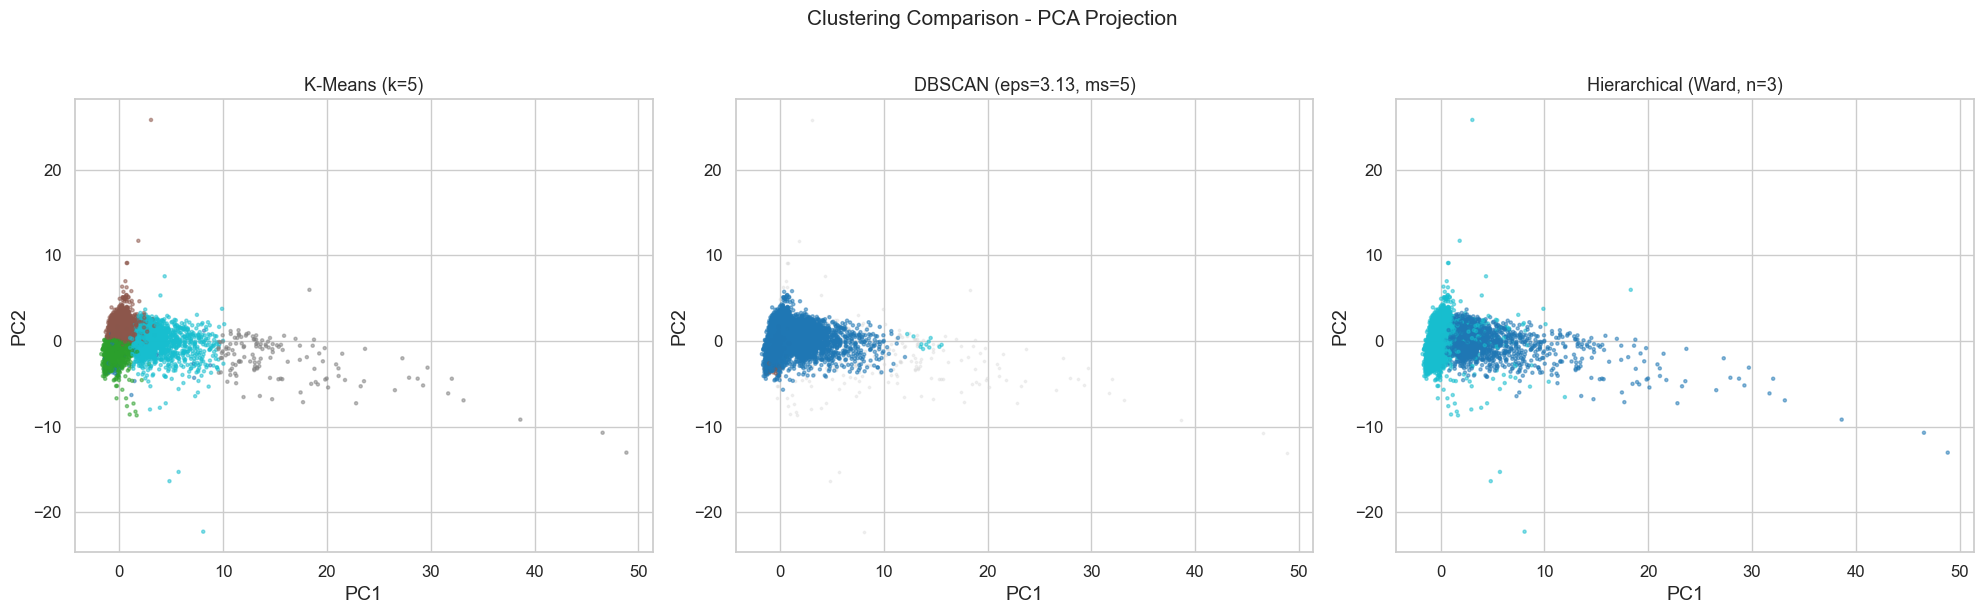

In [29]:
# Side-by-side PCA visualisation of all 3 algorithms
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (col, title) in zip(axes, [
    ('KMeans_Cluster', 'K-Means (k=5)'),
    ('DBSCAN_Cluster', 'DBSCAN (eps=3.13, ms=5)'),
    ('HC_Cluster', 'Hierarchical (Ward, n=3)')
]):
    labels_plot = df[col].values
    if col == 'DBSCAN_Cluster':
        noise = labels_plot == -1
        ax.scatter(X_pca[noise, 0], X_pca[noise, 1], c='lightgrey', s=3, alpha=0.3, label='Noise')
        scatter = ax.scatter(X_pca[~noise, 0], X_pca[~noise, 1],
                             c=labels_plot[~noise], cmap='tab10', s=5, alpha=0.5)
    else:
        scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                             c=labels_plot, cmap='tab10', s=5, alpha=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Clustering Comparison - PCA Projection', fontsize=15, y=1.02)
plt.tight_layout()
save_plot(fig, 'clustering_comparison.png')
plt.show()

**Discussion:** The three PCA projections show visually how each algorithm partitions the same 2D space (35.2% of variance):

- **K-Means (k=5):** Creates 5 regions separated by decision boundaries. The rightmost cluster (Cluster 3, red) is visually distinct — these are the 211 elite games with extreme NumOwned values. The remaining four clusters overlap heavily in 2D, confirming they are separated by features not captured by PC1/PC2.
- **DBSCAN:** The grey noise points (260 games) sit at the far right of the PC1 axis — exactly where the most popular games live. The coloured Cluster 1 (large-group games) forms a visible separate band in the lower region. Cluster 0 occupies the central mass.
- **Hierarchical (Ward n=2):** The clearest visual split: Cluster 0 (purple, elite) is concentrated on the right side of PC1, Cluster 1 (yellow, mainstream) fills the left and centre. The horizontal axis PC1 represents popularity, confirming that the primary split is on community engagement metrics.

In [30]:
# Adjusted Rand Index (ARI) and Normalised Mutual Information (NMI) vs Rating
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

rating_encoded = df['Rating'].map({'Low': 0, 'Medium': 1, 'High': 2}).values

ext_results = []
for col, name in [('KMeans_Cluster', 'K-Means'),
                   ('DBSCAN_Cluster', 'DBSCAN'),
                   ('HC_Cluster', 'Hierarchical')]:
    labels_ext = df[col].values
    if col == 'DBSCAN_Cluster':
        mask = labels_ext != -1
        ari = adjusted_rand_score(rating_encoded[mask], labels_ext[mask])
        nmi = normalized_mutual_info_score(rating_encoded[mask], labels_ext[mask])
    else:
        ari = adjusted_rand_score(rating_encoded, labels_ext)
        nmi = normalized_mutual_info_score(rating_encoded, labels_ext)
    ext_results.append({'Algorithm': name, 'ARI': round(ari, 4), 'NMI': round(nmi, 4)})

ext_df = pd.DataFrame(ext_results)
print("External Validation vs Rating:")
print(ext_df.to_string(index=False))

External Validation vs Rating:
   Algorithm    ARI    NMI
     K-Means 0.0802 0.0916
      DBSCAN 0.0005 0.0020
Hierarchical 0.0285 0.0580


**Discussion:** The ARI and NMI vs Rating confirm what the cluster profiles already suggested:

- **K-Means ARI=0.080, NMI=0.092:** The best external alignment. The 5-cluster solution genuinely captures quality structure — Cluster 3 (82.8% High) and Cluster 1 (47.5% Low) are pulling the score up. This is not high enough to replace a classifier, but it shows the clustering is not random.
- **DBSCAN ARI=0.001, NMI=0.002:** Essentially zero correspondence with Rating labels. Despite DBSCAN's impressive internal silhouette (0.657), its cluster assignments add almost no information about Rating. This is because 93% of games are in Cluster 0, and within that cluster the Rating distribution is indistinguishable from the overall average. The small elite clusters (2 and noise) do align perfectly with High Rating, but they are too few in number to move the global ARI.
- **Hierarchical ARI=0.028, NMI=0.060:** Moderate alignment. The 2-cluster split correctly assigns the popular (56.9% High) vs mainstream (19.8% High) groups, but with only 2 clusters the resolution is insufficient to distinguish Low from Medium within the mainstream.

**Takeaway:** Internally good clusters (high silhouette) do not automatically align with external labels. DBSCAN proves this — the cluster structure it finds is real, but it captures density regions, not rating categories. K-Means' lower internal score but higher external alignment shows it is better calibrated for the task of rating-related segmentation.

---

## Summary

This notebook applied three clustering algorithms to the Board Games dataset (21,925 games, 15 standardised features):

| Algorithm | Best Config | Silhouette | ARI vs Rating | Key Finding |
|-----------|-------------|------------|---------------|-------------|
| K-Means | k=5 | 0.178 | **0.080** | 5 segments; Cluster 3 (211 games) = 82.8% High-rated |
| DBSCAN | eps=3.13, ms=5 | **0.657** | 0.001 | Cluster 2 (100% High); noise = elite outliers |
| Hierarchical | Ward, n=2 | 0.438 | 0.028 | Popular (56.9% High) vs mainstream (19.8% High) |

All three algorithms independently confirm: **popularity metrics (NumOwned, NumWish, NumWeightVotes) are the primary separating axis in this dataset, and highly popular games are almost always highly rated.**

K-Means with k=5 provides the most actionable segmentation for downstream tasks (classification, recommendation).